In [1]:
from five_bar_robot.five_bar import five_bar as five_bar_bot
import five_bar
import time
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import gymnasium as gym
from stable_baselines3 import A2C,PPO,SAC, TD3, DDPG
import mediapy as media
import sympy as sp
import mujoco as mj
plt.rcParams.update({
    "text.usetex": False,  # Use LaTeX for all text (if available)
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": True
})


In [91]:
data_folder = os.path.abspath("data")


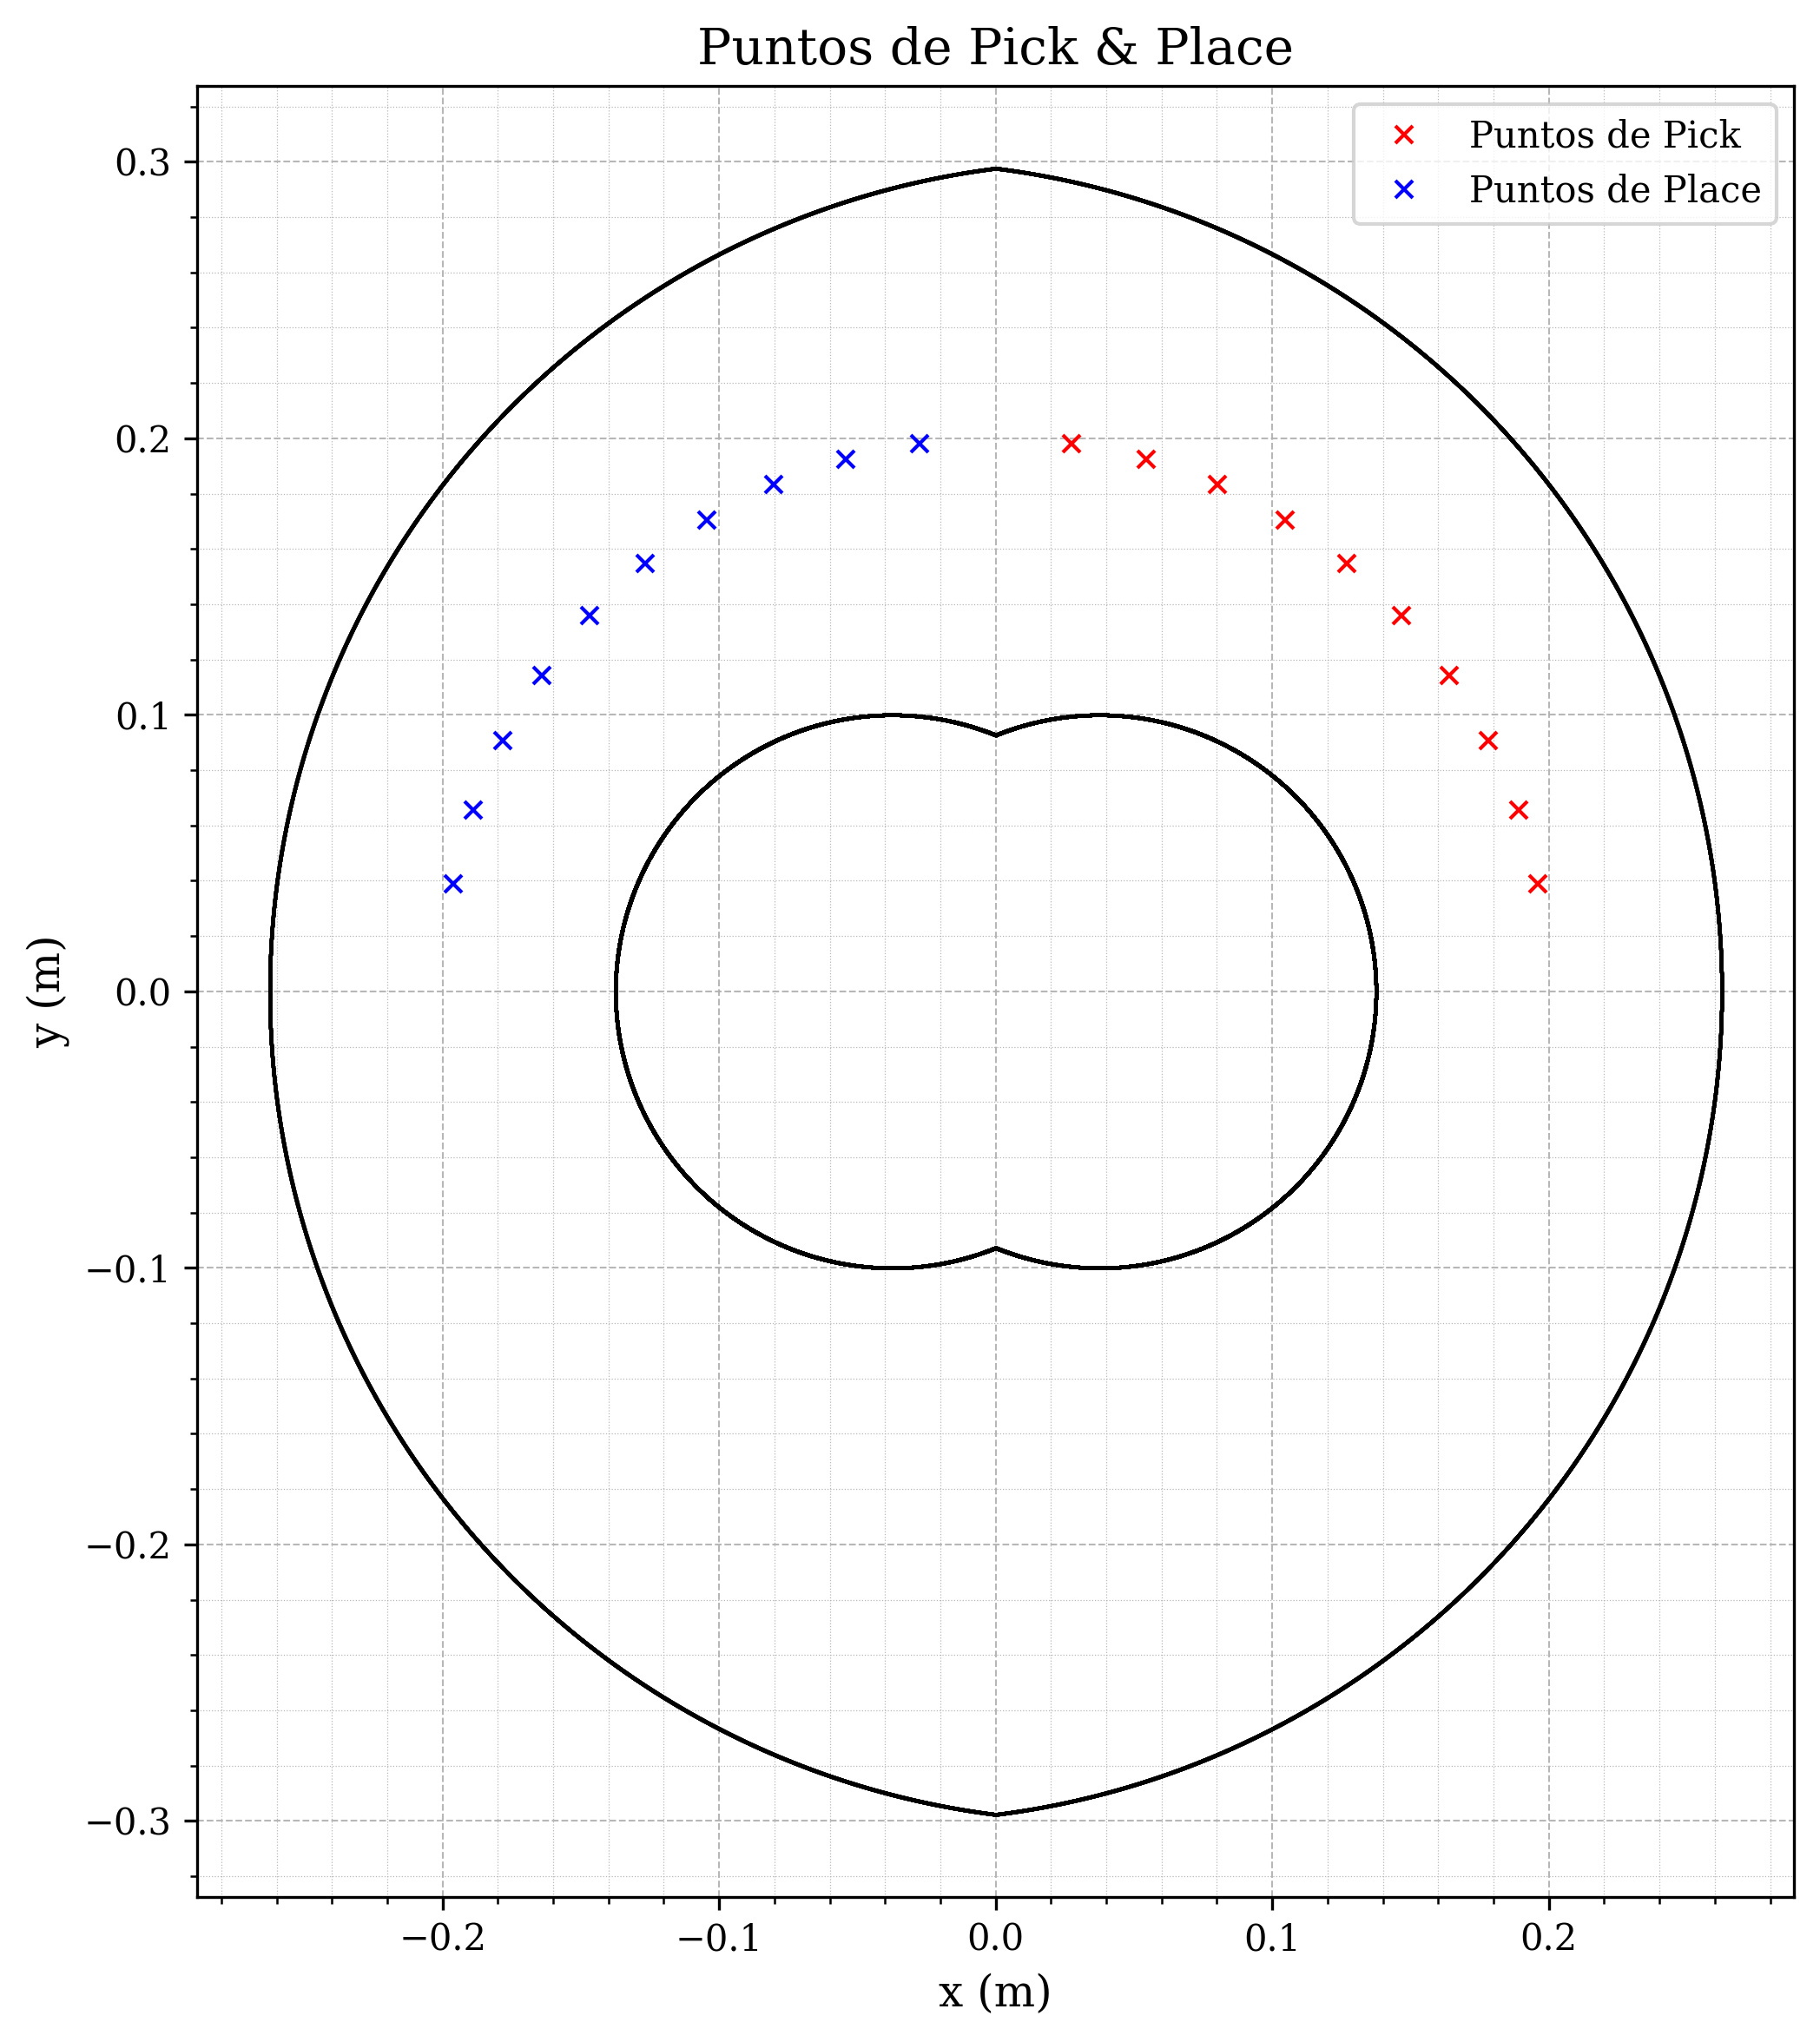

[[[np.float64(0.0274024683363936), np.float64(0.19811386808871545)], [np.float64(-0.0274024683363936), np.float64(0.19811386808871545)]], [[np.float64(0.05428808997301487), np.float64(0.19249104729072947)], [np.float64(-0.05428808997301487), np.float64(0.19249104729072947)]], [[np.float64(0.08014976662062823), np.float64(0.1832375914234272)], [np.float64(-0.08014976662062823), np.float64(0.1832375914234272)]], [[np.float64(0.10449971294318978), np.float64(0.17052803287081844)], [np.float64(-0.10449971294318978), np.float64(0.17052803287081844)]], [[np.float64(0.12687865683272911), np.float64(0.15460209067254738)], [np.float64(-0.12687865683272911), np.float64(0.15460209067254738)]], [[np.float64(0.14686450188713712), np.float64(0.13576014910658835)], [np.float64(-0.14686450188713712), np.float64(0.13576014910658835)]], [[np.float64(0.16408028870510272), np.float64(0.11435759204552245)], [np.float64(-0.16408028870510272), np.float64(0.11435759204552245)]], [[np.float64(0.178201304837673

In [2]:
pts=[]

radii=[0.2]


angles=np.linspace(np.pi/2,np.pi/16,11)
for radius in radii:
    for angle in angles[1:]:
        pts.append([[radius*np.cos(angle),radius*np.sin(angle)],[-radius*np.cos(angle),radius*np.sin(angle)]])
    
def plot_half_ellipse(ax, xc, yc, a, b, x_filter, color, linestyle='--', label=None):
    theta = np.linspace(0, 2*np.pi, 100000)
    x = xc + a * np.cos(theta)
    y = yc + b * np.sin(theta)
    
    if x_filter == '>0':
        mask = x > 0
    elif x_filter == '<0':
        mask = x < 0
    else:
        raise ValueError("x_filter must be '>0' or '<0'")
    
    ax.plot(x[mask], y[mask], color=color, marker="*",linestyle='' ,markersize=0.01,label=label)

# Create plot
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')

# Plot ellipses with original parameters
# Outer (x > 0)
plot_half_ellipse(ax, xc=-0.0375, yc=0.0, a=0.3, b=0.3, x_filter='>0', color='black')
# Inner (x > 0)
plot_half_ellipse(ax, xc=0.0375, yc=0.0, a=0.1, b=0.1, x_filter='>0', color='black')

# Outer (x < 0)
plot_half_ellipse(ax, xc=0.0375, yc=0.0, a=0.3, b=0.3, x_filter='<0', color='black')
# Inner (x < 0)
plot_half_ellipse(ax, xc=-0.0375, yc=0.0, a=0.1, b=0.1, x_filter='<0', color='black')

i=0
for pt in pts:
    if i==0:
        ax.plot(*pt[0],color='red', marker="x",linestyle='' ,markersize=5,label='Puntos de Pick')
        ax.plot(*pt[1],color='blue', marker="x",linestyle='' ,markersize=5,label='Puntos de Place')
        i+=1
    else:
        ax.plot(*pt[0],color='red', marker="x",linestyle='' ,markersize=5)
        ax.plot(*pt[1],color='blue', marker="x",linestyle='' ,markersize=5)
# Format plot

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Puntos de Pick & Place')
ax.grid(True)

ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.9)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.9)
ax.legend()
plt.show()
print(pts)

In [3]:
XML_PATH=os.path.join(os.path.dirname(os.path.abspath("")),"assets",'5_bar_realistic.xml')
model=mj.MjModel.from_xml_path(XML_PATH)
data = mj.MjData(model)

scene_option = mj.MjvOption()
cam = mj.MjvCamera()
cam.type = mj.mjtCamera.mjCAMERA_FREE
cam.fixedcamid = -1  # Free camera mode
cam.distance = 0.75   # Distance from lookat point
cam.azimuth = 90      # Rotation around vertical axis (0 for straight)
cam.elevation = -90  # -90 looks straight down
cam.lookat = np.array([0.0, 0.0, 0.0])

In [4]:
# Dynamics

# Parameters
scale = 0.5

# Motor coordinates
O_1x, O_2x,O_1y, O_2y = -0.075 * scale, 0.075 * scale,0 * scale, 0 * scale

# Link lengths
L_p1, L_p2, L_d1, L_d2 = [0.2 * scale, 0.2 * scale, 0.4 * scale, 0.4 * scale]

# A known configuration for the mechanism
q_base=np.vstack([-0.14571*scale,0.07071*scale,np.deg2rad(135),
     -0.10821*scale,0.30962*scale,np.deg2rad(57.244623466),
     0.10821*scale,0.30962*scale,np.deg2rad(-57.244623466),
     0.14571*scale,0.07071*scale,np.deg2rad(-135)])

# Symbolic variables
t = sp.Symbol('t')

phi_p1, phi_p2, phi_d1, phi_d2 = sp.symbols('phi_p1 phi_p2 phi_d1 phi_d2')
x_p1, y_p1, x_p2, y_p2 = sp.symbols('x_p1 y_p1 x_p2 y_p2')
x_d1, y_d1, x_d2, y_d2 = sp.symbols('x_d1 y_d1 x_d2 y_d2')

dphi_p1, dphi_p2, dphi_d1, dphi_d2 = sp.symbols('dphi_p1 dphi_p2 dphi_d1 dphi_d2')
dx_p1, dy_p1, dx_p2, dy_p2 = sp.symbols('dx_p1 dy_p1 dx_p2 dy_p2')
dx_d1, dy_d1, dx_d2, dy_d2 = sp.symbols('dx_d1 dy_d1 dx_d2 dy_d2')


# Rotation matrix function (symbolic and numeric)
def rotmat(phi):
    return sp.Matrix([[sp.cos(phi), -sp.sin(phi)], [sp.sin(phi), sp.cos(phi)]])

def rotmat_num(phi):
    return np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])

# Generalized coordinates vector
q = sp.Matrix([x_p1, y_p1, phi_p1, x_d1, y_d1, phi_d1, x_d2, y_d2, phi_d2, x_p2, y_p2, phi_p2])
dq = sp.Matrix([dx_p1, dy_p1, dphi_p1, dx_d1, dy_d1, dphi_d1, dx_d2, dy_d2, dphi_d2, dx_p2, dy_p2, dphi_p2])

# Number of generalized coordinates
nq=len(q)

# The inverse is defined as a symolic variable to avoid the analytical calculation of the inverse of the jacobian
inv_PHI_q=sp.MatrixSymbol('inv_PHI_q', nq, nq)

# Joint equations

# Proximal link 1 - Ground
eq1 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([-L_p1 / 2, 0]) - sp.Matrix([O_1x, O_1y])

# Proximal link 1 - Distal Link 1
eq2 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([L_p1 / 2, 0]) - (sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([-L_d1 / 2, 0]))

#  Proximal link 1 - Distal Link 1
eq3 = sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0]) - (sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([-L_d2 / 2, 0]))

# Distal Link 2 - Proximal Link 2
eq4 = sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([L_d2 / 2, 0]) - (sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([-L_p2 / 2, 0]))

# Proximal Link 2 - Ground
eq5 = sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([L_p2 / 2, 0]) - sp.Matrix([O_2x, O_2y])


# Time-dependent symbolic variables
sym_phi_p1 = sp.Function('sym_phi_p1')(t)
sym_phi_p2 = sp.Function('sym_phi_p2')(t)
sym_phi_p1_dot, sym_phi_p2_dot = sp.symbols('sym_phi_p1_dot sym_phi_p2_dot')
sym_phi_p1_dotdot, sym_phi_p2_dotdot = sp.symbols('sym_phi_p1_dotdot sym_phi_p2_dotdot')

# Actuaction Equations
eq6_direct = sp.Matrix([phi_p1, phi_p2]) - sp.Matrix([sym_phi_p1, sym_phi_p2])

# Constraint vector
PHI_direct = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6_direct))

# Calculates Jacobian
PHI_q_direct = PHI_direct.jacobian(q)

#Calculates first derivative
dq_eq_direct=-inv_PHI_q@PHI_direct.diff(t)

#Calculates second derivative
ddq_eq_direct=-inv_PHI_q@(((PHI_q_direct@dq).jacobian(q))@dq+2*PHI_q_direct.diff(t)@dq+PHI_direct.diff(t, t))

dq_eq_subs_direct = dq_eq_direct.subs({
    sp.Derivative(sym_phi_p1, t): sym_phi_p1_dot,
    sp.Derivative(sym_phi_p2, t): sym_phi_p2_dot
})

ddq_eq_subs_direct = ddq_eq_direct.subs({
    sp.Derivative(sym_phi_p1, t): sym_phi_p1_dot,
    sp.Derivative(sym_phi_p2, t): sym_phi_p2_dot,
    sp.Derivative(sp.Derivative(sym_phi_p1, t),t): sym_phi_p1_dotdot,
    sp.Derivative(sp.Derivative(sym_phi_p2, t),t): sym_phi_p2_dotdot
})

# Convert symbolic expressions to numerical functions
PHI_fun_direct = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_direct, 'numpy')
PHI_q_fun_direct = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_q_direct, 'numpy')

dq_fun_direct = sp.lambdify((q, inv_PHI_q, sym_phi_p1_dot, sym_phi_p2_dot), dq_eq_subs_direct, 'numpy')
ddq_fun_direct= sp.lambdify((q,dq, inv_PHI_q, sym_phi_p1_dot, sym_phi_p2_dot,sym_phi_p1_dotdot,sym_phi_p2_dotdot), ddq_eq_subs_direct, 'numpy')


def direct_kinematics(q_0,phi_p1_val,phi_p2_val,dphi_p1_val,dphi_p2_val,ddphi_p1_val,ddphi_p2_val):
    # Newton - Rhapson Solver Parameters
    tol=1e-6
    max_iters=100
 
    j=1 # Reset iteration counter
    q_0=np.vstack(q_0) # Use random solution as the initial guess for the next iteration
    
    while True:

        phi_val=PHI_fun_direct(q_0.flatten(),phi_p1_val,phi_p2_val)
        
        phi_q_val=PHI_q_fun_direct(q_0.flatten(),phi_p1_val,phi_p2_val)
        
        inv_phi_q_val=np.linalg.inv(phi_q_val)
        
        q_1=q_0-inv_phi_q_val@phi_val
        
        if j>max_iters:
            return None
        
        if max(abs(phi_val))<=tol:
            
            q_sol=q_0.flatten()
            
            dq_sol = dq_fun_direct(q_sol, inv_phi_q_val, dphi_p1_val, dphi_p2_val).flatten()
            
            ddq_sol = ddq_fun_direct(q_sol,dq_sol, inv_phi_q_val, dphi_p1_val, dphi_p2_val,ddphi_p1_val,ddphi_p2_val).flatten()
            
            return q_sol,dq_sol,ddq_sol,phi_q_val
        q_0=q_1
        j+=1

# Time-dependent symbolic variables
sym_effx = sp.Function('sym_effx')(t)
sym_effy = sp.Function('sym_effy')(t)
sym_effx_dot, sym_effy_dot = sp.symbols('sym_effx_dot sym_effy_dot')
sym_effx_dotdot, sym_effy_dotdot = sp.symbols('sym_effx_dotdot sym_effy_dotdot')

# Actuaction Equations
eq6_inverse = sp.Matrix([sym_effx, sym_effy])-sp.Matrix([x_d1, y_d1]) - rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0])

# Constraint vector
PHI_inverse = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6_inverse))

# Calculates Jacobian
PHI_q_inverse = PHI_inverse.jacobian(q)

#Calculates first derivative
dq_eq_inverse=-inv_PHI_q@PHI_inverse.diff(t)

#Calculates second derivative
ddq_eq_inverse=-inv_PHI_q@(((PHI_q_inverse@dq).jacobian(q))@dq+2*PHI_q_inverse.diff(t)@dq+PHI_inverse.diff(t, t))

dq_eq_subs_inverse = dq_eq_inverse.subs({
    sp.Derivative(sym_effx, t): sym_effx_dot,
    sp.Derivative(sym_effy, t): sym_effy_dot
})

ddq_eq_subs_inverse = ddq_eq_inverse.subs({
    sp.Derivative(sym_effx, t): sym_effx_dot,
    sp.Derivative(sym_effy, t): sym_effy_dot,
    sp.Derivative(sp.Derivative(sym_effx, t),t): sym_effx_dotdot,
    sp.Derivative(sp.Derivative(sym_effy, t),t): sym_effy_dotdot
})

# Convert symbolic expressions to numerical functions
PHI_fun_inverse = sp.lambdify((q, sym_effx,sym_effy), PHI_inverse, 'numpy')
PHI_q_fun_inverse = sp.lambdify((q, sym_effx,sym_effy), PHI_q_inverse, 'numpy')

dq_fun_inverse = sp.lambdify((q, inv_PHI_q, sym_effx_dot, sym_effy_dot), dq_eq_subs_inverse, 'numpy')
ddq_fun_inverse= sp.lambdify((q,dq, inv_PHI_q, sym_effx_dot, sym_effy_dot,sym_effx_dotdot,sym_effy_dotdot), ddq_eq_subs_inverse, 'numpy')


def inverse_kinematics(q_0,effx_val,effy_val,deffx_val,deffy_val,ddeffx_val,ddeffy_val):
    # Newton - Rhapson Solver Parameters
    tol=1e-6
    max_iters=100
 
    j=1 # Reset iteration counter
    q_0=np.vstack(q_0) # Use random solution as the initial guess for the next iteration
    
    while True:

        phi_val=PHI_fun_inverse(q_0.flatten(),effx_val,effy_val)
        
        phi_q_val=PHI_q_fun_inverse(q_0.flatten(),effx_val,effy_val)
        
        inv_phi_q_val=np.linalg.inv(phi_q_val)
        
        q_1=q_0-inv_phi_q_val@phi_val
        
        if j>max_iters:
            return None
        
        if max(abs(phi_val))<=tol:
            
            q_sol=q_0.flatten()
            
            dq_sol = dq_fun_inverse(q_sol, inv_phi_q_val, deffx_val, deffy_val).flatten()
            
            ddq_sol = ddq_fun_inverse(q_sol,dq_sol, inv_phi_q_val, deffx_val, deffy_val,ddeffx_val,ddeffy_val).flatten()
            
            return q_sol,dq_sol,ddq_sol,phi_q_val
        q_0=q_1
        j+=1

In [5]:
#polynomials
def quintic_trajectory(T,theta_i, theta_f, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0):
    """
    Returns the coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5
    that interpolates position, velocity, and acceleration at t=0 and t=T.
    """
    a0 = theta_i
    a1 = speed_i
    a2 = acceleration_i / 2

    # Setup linear system for [a3, a4, a5]
    A = np.array([
        [T**3,    T**4,     T**5],
        [3*T**2,  4*T**3,   5*T**4],
        [6*T,     12*T**2,  20*T**3]
    ])
    B = np.array([
        theta_f - (a0 + a1*T + a2*T**2),
        speed_f - (a1 + 2*a2*T),
        acceleration_f - (2*a2)
    ])

    a3, a4, a5 = np.linalg.solve(A, B)

    return [a0, a1, a2, a3, a4, a5]

def evaluate_quintic(coeffs, t, T):
    """
    Evaluates θ(t), θ̇(t), and θ̈(t) for a quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5

    Args:
        coeffs (list): Coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial.
        t (float): Time at which to evaluate.
        T (float): Total duration, used to clamp t between 0 and T.

    Returns:
        list: [θ(t), θ̇(t), θ̈(t)]
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    
    t = max(0, min(t, T))  # Clamp t to [0, T]

    theta = a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
    theta_dot = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
    theta_dotdot = 2*a2 + 6*a3*t + 12*a4*t**2 + 20*a5*t**3

    return theta, theta_dot, theta_dotdot

In [6]:
#RL Load
RL_model_names=["sac_enA-9.41_diA-6.38_enB-6.95_diB-7.68","sac_enA-9.40_diA-6.38_enB-6.95_diB-7.68","ppo_enA-9.40_diA-6.38_enB-6.95_diB-7.68","td3_enA-9.40_diA-6.38_enB-6.95_diB-7.68"]
def model_load(env,RL_model_name):
    
    algo_name=RL_model_name.split("_")[0]
        
    path=os.path.join(os.path.dirname(os.getcwd()),"RL","trained_agents",RL_model_name,"agent.zip")
    
    if algo_name.lower() == 'ddpg':
        model = DDPG.load(path, env=env)
    elif algo_name.lower() == 'ppo':
        model = PPO.load(path, env=env)
    elif algo_name.lower() == 'a2c':
        model = A2C.load(path, env=env)
    elif algo_name.lower() == 'sac':
        model = SAC.load(path, env=env)
    elif algo_name.lower() == 'td3':
        model = TD3.load(path, env=env)
    else:
        raise ValueError(f"Algorithm {algo_name} not recognized. Please choose 'ddpg', 'ppo', 'a2c', 'sac' or td3.")
    
    return model

In [7]:
RL_env = gym.make("five_bar-v0")
RL_model=model_load(RL_env,RL_model_names[0])

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [8]:
#q_sol,dq_sol,ddq_sol,phi_q_val=inverse_kinematics(q_0,effx_val,effy_val,deffx_val,deffy_val,ddeffx_val,ddeffy_val)
#q_sol,dq_sol,ddq_sol,phi_q_val=direct_kinematics(q_0,phi_p1_val,phi_p2_val,dphi_p1_val,dphi_p2_val,ddphi_p1_val,ddphi_p2_val)
# [a0, a1, a2, a3, a4, a5]=quintic_trajectory(T,theta_i, theta_f, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0)
# [theta, theta_dot, theta_dotdot]=evaluate_quintic(coeffs, t, T)
q_pick,_,_,_=inverse_kinematics(q_base,*pts[0][0],0,0,0,0)
q_place,_,_,_=inverse_kinematics(q_base,*pts[0][1],0,0,0,0)

qs_pick=[]
qs_place=[]

qs_pick.append(q_pick)
qs_place.append(q_place)

for i in range(len(pts)-1):
    
    q_pick,_,_,_=inverse_kinematics(qs_pick[i],*pts[i+1][0],0,0,0,0)
    q_place,_,_,_=inverse_kinematics(qs_place[i],*pts[i+1][1],0,0,0,0)
    qs_pick.append(q_pick)
    qs_place.append(q_place)

go_trajectories_coeffs_theta1=[]
go_trajectories_coeffs_theta2=[]

back_trajectories_coeffs_theta1=[]
back_trajectories_coeffs_theta2=[]

trajectory_times=[0.30,0.3,0.375,0.5,0.5,0.5,0.5,0.5,0.55,0.55]
#trajectory_times=[0.55,0.55,0.55,0.55,0.55,0.55,0.55,0.55,0.55,0.75]

for i in range(len(pts)):
    q_pick_temp=qs_pick[i]
    q_place_temp=qs_place[i]
    
    go_trajectories_coeffs_theta1.append(quintic_trajectory(trajectory_times[i],qs_pick[i][2], qs_place[i][2]))
    go_trajectories_coeffs_theta2.append(quintic_trajectory(trajectory_times[i],qs_pick[i][11], qs_place[i][11]))
    
    back_trajectories_coeffs_theta1.append(quintic_trajectory(trajectory_times[i],qs_place[i][2], qs_pick[i][2]))
    back_trajectories_coeffs_theta2.append(quintic_trajectory(trajectory_times[i],qs_place[i][11], qs_pick[i][11]))

In [9]:
robot = five_bar_bot(SERIAL_PORT="COM3", max_speed=600)

target1=135
target2=-135

robot.set_control_mode("position",target1,target2)

robot.start()


Initializing Robot...

Connecting to CAN bus COM3...
Successfully connected to CAN bus COM3!

Robot Initialized. 
Defaulting to control mode: 'torque'
Start threads to begin using the robot

Control Mode set to 'position'. Setting targets to [135, -135]

Starting Read/write threads...
Read/write threads started!



Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]
Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]


In [90]:
robot.set_control_mode('position',np.rad2deg(qs_pick[0][2]),np.rad2deg(qs_pick[0][11]))


Control Mode set to 'position'. Setting targets to [np.float64(143.02540150227918), np.float64(-163.44947473610605)]



In [36]:
robot.reactivate()

In [82]:

robot.set_control_mode('torque')
rb_data=robot.get_motors_data()
rb_angles=np.deg2rad(rb_data['angle'])
rb_speed=np.deg2rad(rb_data['speed'])
q_rb,dq_rb,_,_=direct_kinematics(q_base,rb_angles[0],rb_angles[1],rb_speed[0],rb_speed[1],0,0)
q_rb_est=q_rb
rb_eff=[q_rb[3]+0.1*np.cos(q_rb[5]),q_rb[4]+0.1*np.sin(q_rb[5])]

pickplace_mode = 1
mode_durations = {1: 1.0, 2: 1.0, 3: 1.5, 4: 1.5}


duration=100

t_init=time.time()
dt=0.01

data_log_quintic=[]
trajectory_num=0

actual_coeffs_theta1=go_trajectories_coeffs_theta1[0]
actual_coeffs_theta2=go_trajectories_coeffs_theta2[0]

t_0=time.time()
while time.time()-t_init<duration:
    
    rb_data=robot.get_motors_data()
    rb_angles=np.deg2rad(rb_data['angle'])
    rb_speed=np.deg2rad(rb_data['speed'])
    q_rb,dq_rb,_,_=direct_kinematics(q_rb_est,rb_angles[0],rb_angles[1],rb_speed[0],rb_speed[1],0,0)
    rb_eff=[q_rb[3]+0.1*np.cos(q_rb[5]),q_rb[4]+0.1*np.sin(q_rb[5])]
    q_est=q_rb+dt*dq_rb
    
    obj_theta1,obj_dtheta1,_=evaluate_quintic(actual_coeffs_theta1, time.time()-t_0, trajectory_times[trajectory_num])
    obj_theta2,obj_dtheta2,_=evaluate_quintic(actual_coeffs_theta2, time.time()-t_0, trajectory_times[trajectory_num])
    
    target1=0.04*np.rad2deg(obj_theta1-rb_angles[0])+0.007*np.rad2deg(obj_dtheta1-rb_speed[0])
    target2=0.04*np.rad2deg(obj_theta2-rb_angles[1])+0.007*np.rad2deg(obj_dtheta2-rb_speed[1])
    
    robot.set_target(target1,target2)
    
    
    
    if time.time() - t_0 > mode_durations[pickplace_mode]:
        t_0 = time.time()

        if pickplace_mode == 1:
            # place → pick (same)
            actual_coeffs_theta1 = back_trajectories_coeffs_theta1[trajectory_num]
            actual_coeffs_theta2 = back_trajectories_coeffs_theta2[trajectory_num]
            pickplace_mode = 2

        elif pickplace_mode == 2:
            # go again to same place
            actual_coeffs_theta1 = go_trajectories_coeffs_theta1[trajectory_num]
            actual_coeffs_theta2 = go_trajectories_coeffs_theta2[trajectory_num]
            pickplace_mode = 3

        elif pickplace_mode == 3:
            # back to pick of next trajectory
            if trajectory_num + 1 < len(go_trajectories_coeffs_theta1):
                actual_coeffs_theta1 = back_trajectories_coeffs_theta1[trajectory_num + 1]
                actual_coeffs_theta2 = back_trajectories_coeffs_theta2[trajectory_num + 1]
                pickplace_mode = 4
            else:
                break  # finished all

        elif pickplace_mode == 4:
            trajectory_num += 1
            if trajectory_num < len(go_trajectories_coeffs_theta1):
                actual_coeffs_theta1 = go_trajectories_coeffs_theta1[trajectory_num]
                actual_coeffs_theta2 = go_trajectories_coeffs_theta2[trajectory_num]
                pickplace_mode = 1
            else:
                break

    # === Logging: only for pick→place and place→pick ===
    if pickplace_mode in [1, 2]:
        data_log_quintic.append({
            'trajectory_num': trajectory_num,
            'pick_place_mode': pickplace_mode,
            'time': time.time() - t_0,
            'torque1': target1,
            'torque2': target2,
            'theta1': rb_angles[0],
            'theta2': rb_angles[1],
            'omega1': rb_speed[0],
            'omega2': rb_speed[1],
            'eff_x': q_rb[3]+0.1*np.cos(q_rb[5]),
            'eff_y': q_rb[4]+0.1*np.sin(q_rb[5]),
        })
    time.sleep(dt)


Control Mode set to 'torque'. Setting targets to [0, 0]



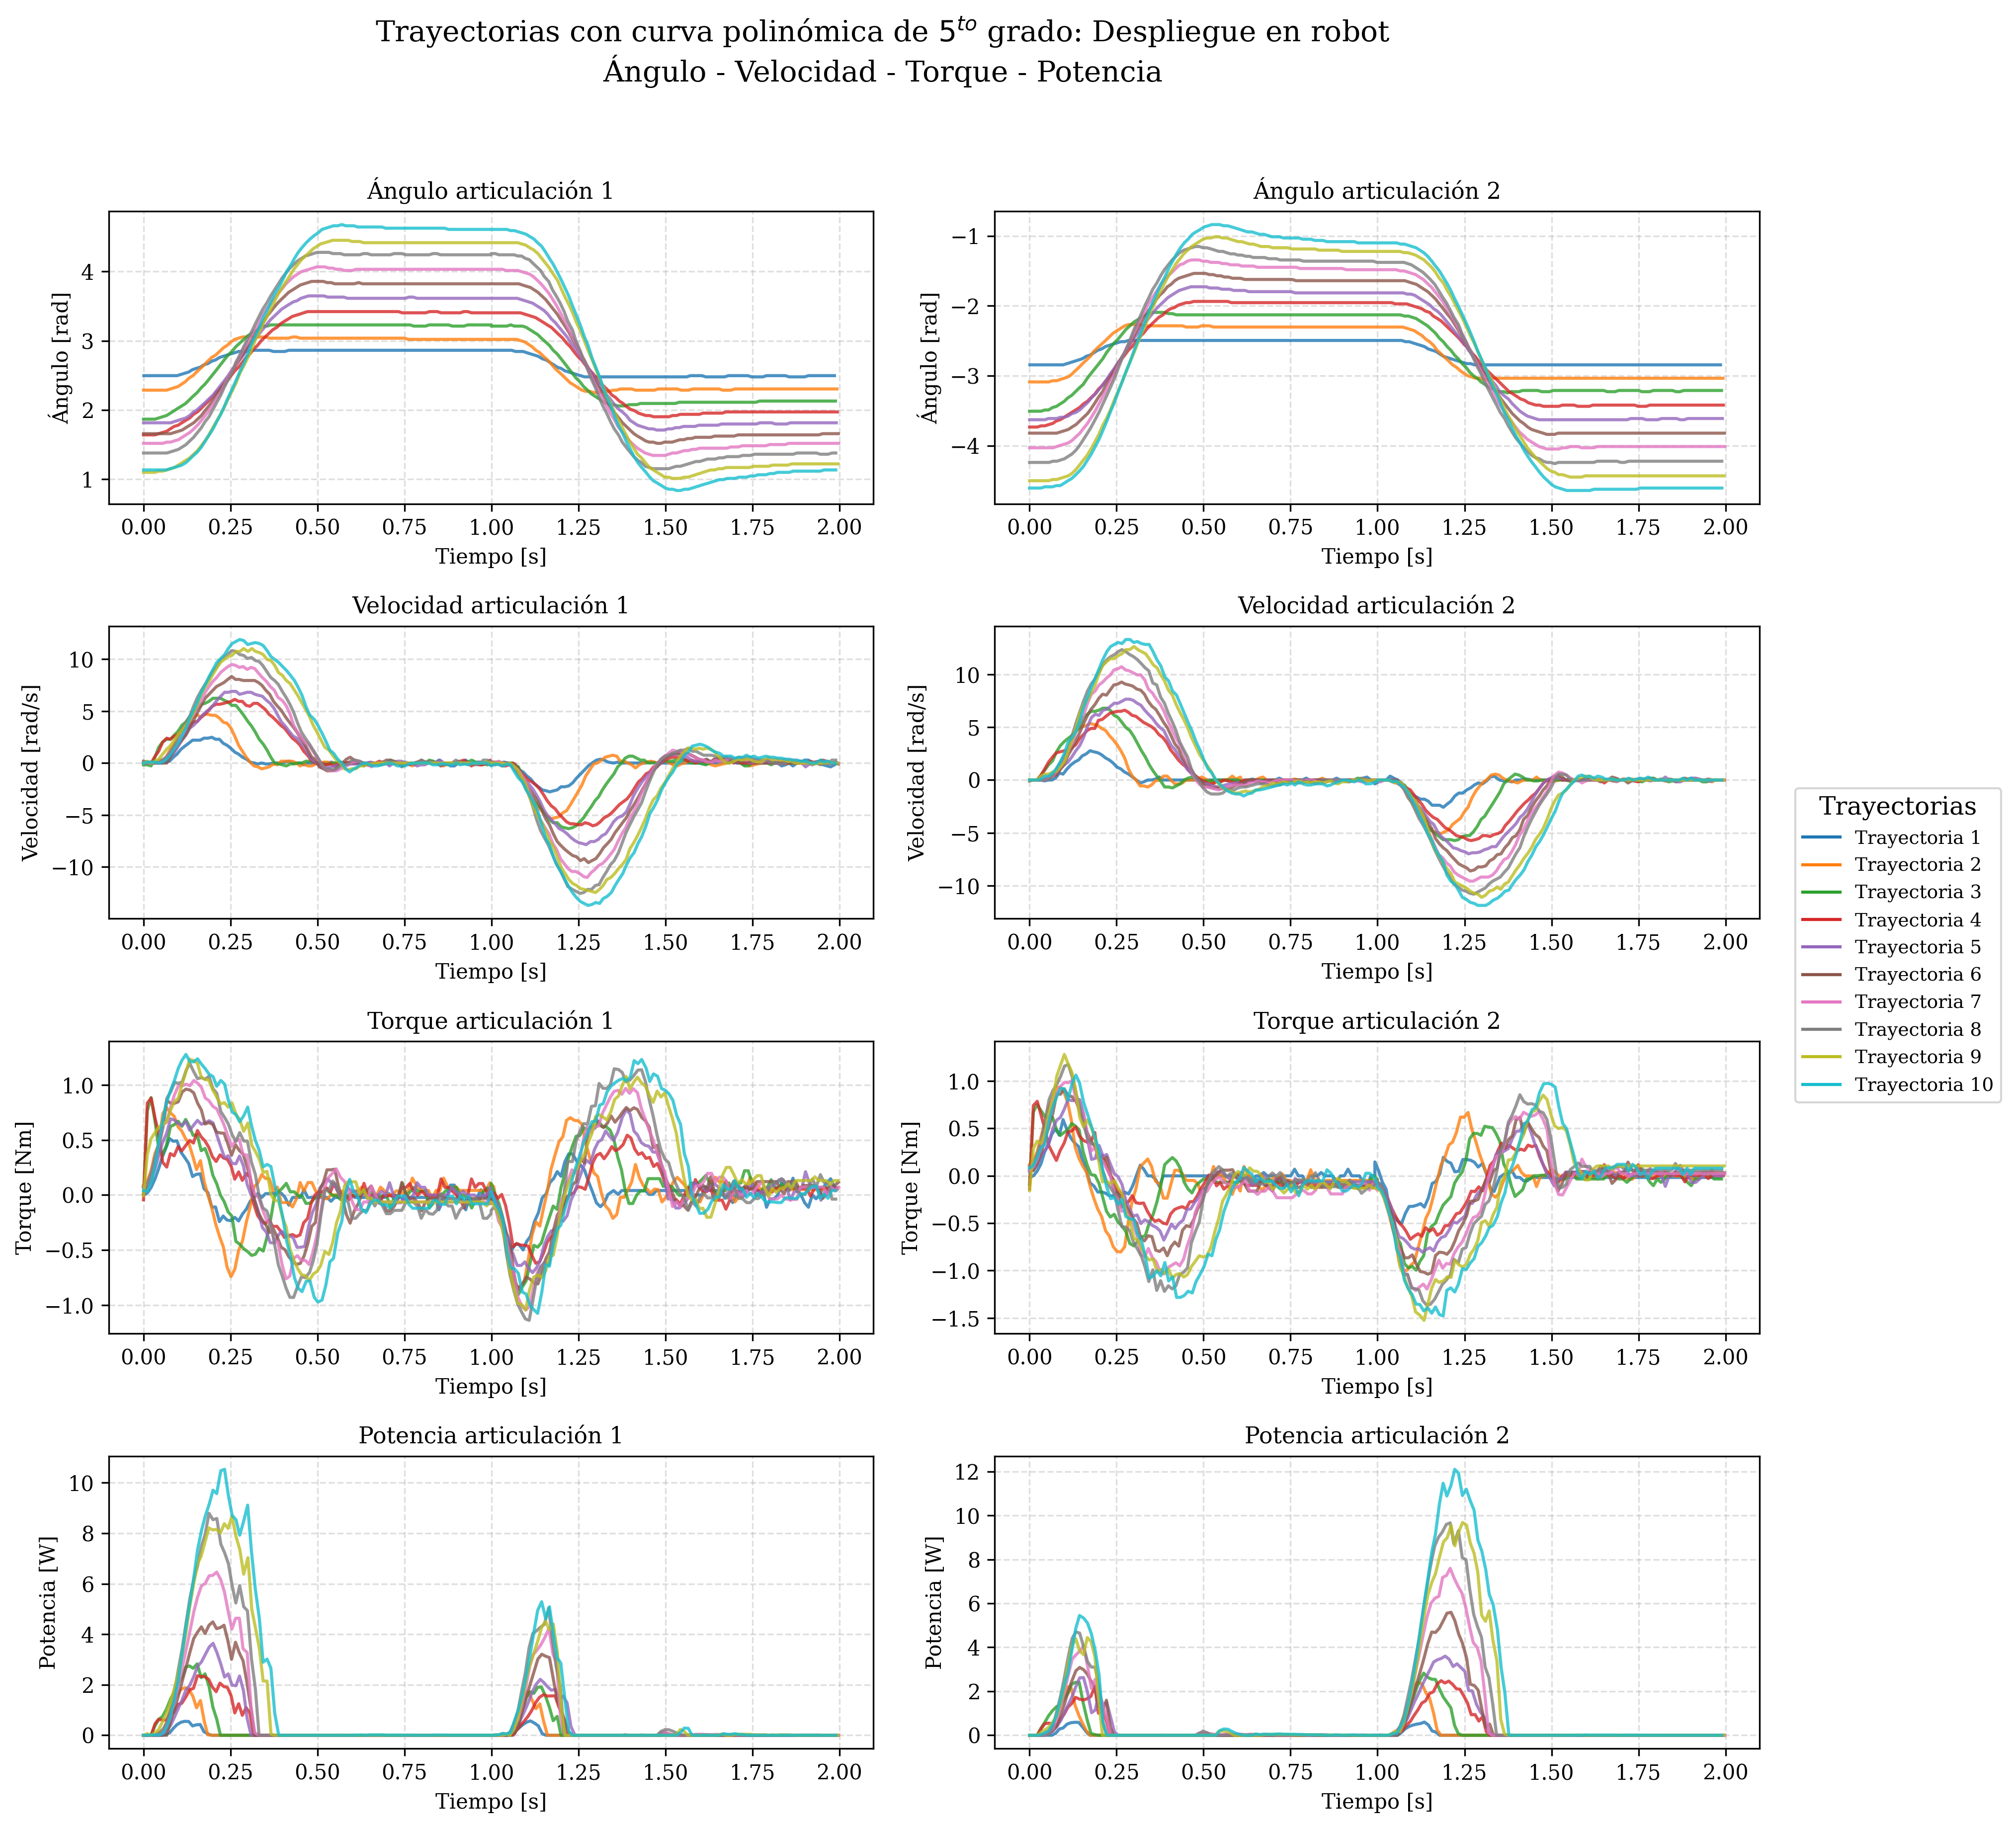

In [73]:


# === Load and prepare data ===
df_quintic = pd.DataFrame(data_log_quintic)

# === Compute positive joint power ===
df_quintic['power1'] = np.maximum(df_quintic['torque1'] * df_quintic['omega1'], 0)
df_quintic['power2'] = np.maximum(df_quintic['torque2'] * df_quintic['omega2'], 0)

# === Unique trajectory IDs ===
traj_ids = sorted(df_quintic['trajectory_num'].unique())

# === Create 4x2 plot: angle, velocity, torque, power ===
fig, axes = plt.subplots(4, 2, figsize=(12, 12), sharex=False)
color_map = plt.get_cmap("tab10")
legend_lines = []

for i, traj_id in enumerate(traj_ids):
    # Split phases
    phase1 = df_quintic[(df_quintic['trajectory_num'] == traj_id) & (df_quintic['pick_place_mode'] == 1)]
    phase2 = df_quintic[(df_quintic['trajectory_num'] == traj_id) & (df_quintic['pick_place_mode'] == 2)]

    if phase1.empty or phase2.empty:
        continue

    # Time stitching
    t1 = phase1['time'].values
    t2 = phase2['time'].values + t1[-1]
    t_all = np.concatenate([t1, t2])

    color = color_map(i % 10)

    # Data concatenation
    theta1 = np.concatenate([phase1['theta1'].values, phase2['theta1'].values])
    theta2 = np.concatenate([phase1['theta2'].values, phase2['theta2'].values])
    omega1 = np.concatenate([phase1['omega1'].values, phase2['omega1'].values])
    omega2 = np.concatenate([phase1['omega2'].values, phase2['omega2'].values])
    torque1 = np.concatenate([phase1['torque1'].values, phase2['torque1'].values])
    torque2 = np.concatenate([phase1['torque2'].values, phase2['torque2'].values])
    power1 = np.concatenate([phase1['power1'].values, phase2['power1'].values])
    power2 = np.concatenate([phase1['power2'].values, phase2['power2'].values])

    # Plotting
    axes[0, 0].plot(t_all, theta1, color=color, alpha=0.8)
    axes[0, 1].plot(t_all, theta2, color=color, alpha=0.8)
    axes[1, 0].plot(t_all, omega1, color=color, alpha=0.8)
    axes[1, 1].plot(t_all, omega2, color=color, alpha=0.8)
    axes[2, 0].plot(t_all, torque1, color=color, alpha=0.8)
    axes[2, 1].plot(t_all, torque2, color=color, alpha=0.8)
    axes[3, 0].plot(t_all, power1, color=color, alpha=0.8)
    axes[3, 1].plot(t_all, power2, color=color, alpha=0.8)

    legend_lines.append(plt.Line2D([], [], color=color, label=f"Trayectoria {traj_id+1}"))

# === Titles and labels ===
titles = [["Ángulo articulación 1", "Ángulo articulación 2"],
          ["Velocidad articulación 1", "Velocidad articulación 2"],
          ["Torque articulación 1", "Torque articulación 2"],
          ["Potencia articulación 1", "Potencia articulación 2"]]

ylabels = [["Ángulo [rad]"]*2,
           ["Velocidad [rad/s]"]*2,
           ["Torque [Nm]"]*2,
           ["Potencia [W]"]*2]

for row in range(4):
    for col in range(2):
        ax = axes[row, col]
        ax.set_title(titles[row][col], fontsize=11)
        ax.set_ylabel(ylabels[row][col], fontsize=10)
        ax.set_xlabel("Tiempo [s]", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)

# === Global legend ===
fig.legend(handles=legend_lines, loc='center left', bbox_to_anchor=(1.01, 0.5),
           borderaxespad=0, fontsize=9, title="Trayectorias")

plt.suptitle("Trayectorias con curva polinómica de $5^{to}$ grado: Despliegue en robot \nÁngulo - Velocidad - Torque - Potencia", fontsize=14, y=1.02)

plt.tight_layout()
plt.subplots_adjust(right=0.99)
plt.show()


In [92]:
df_quintic.to_csv(os.path.join(data_folder, 'df_quintic.csv'), index=False)

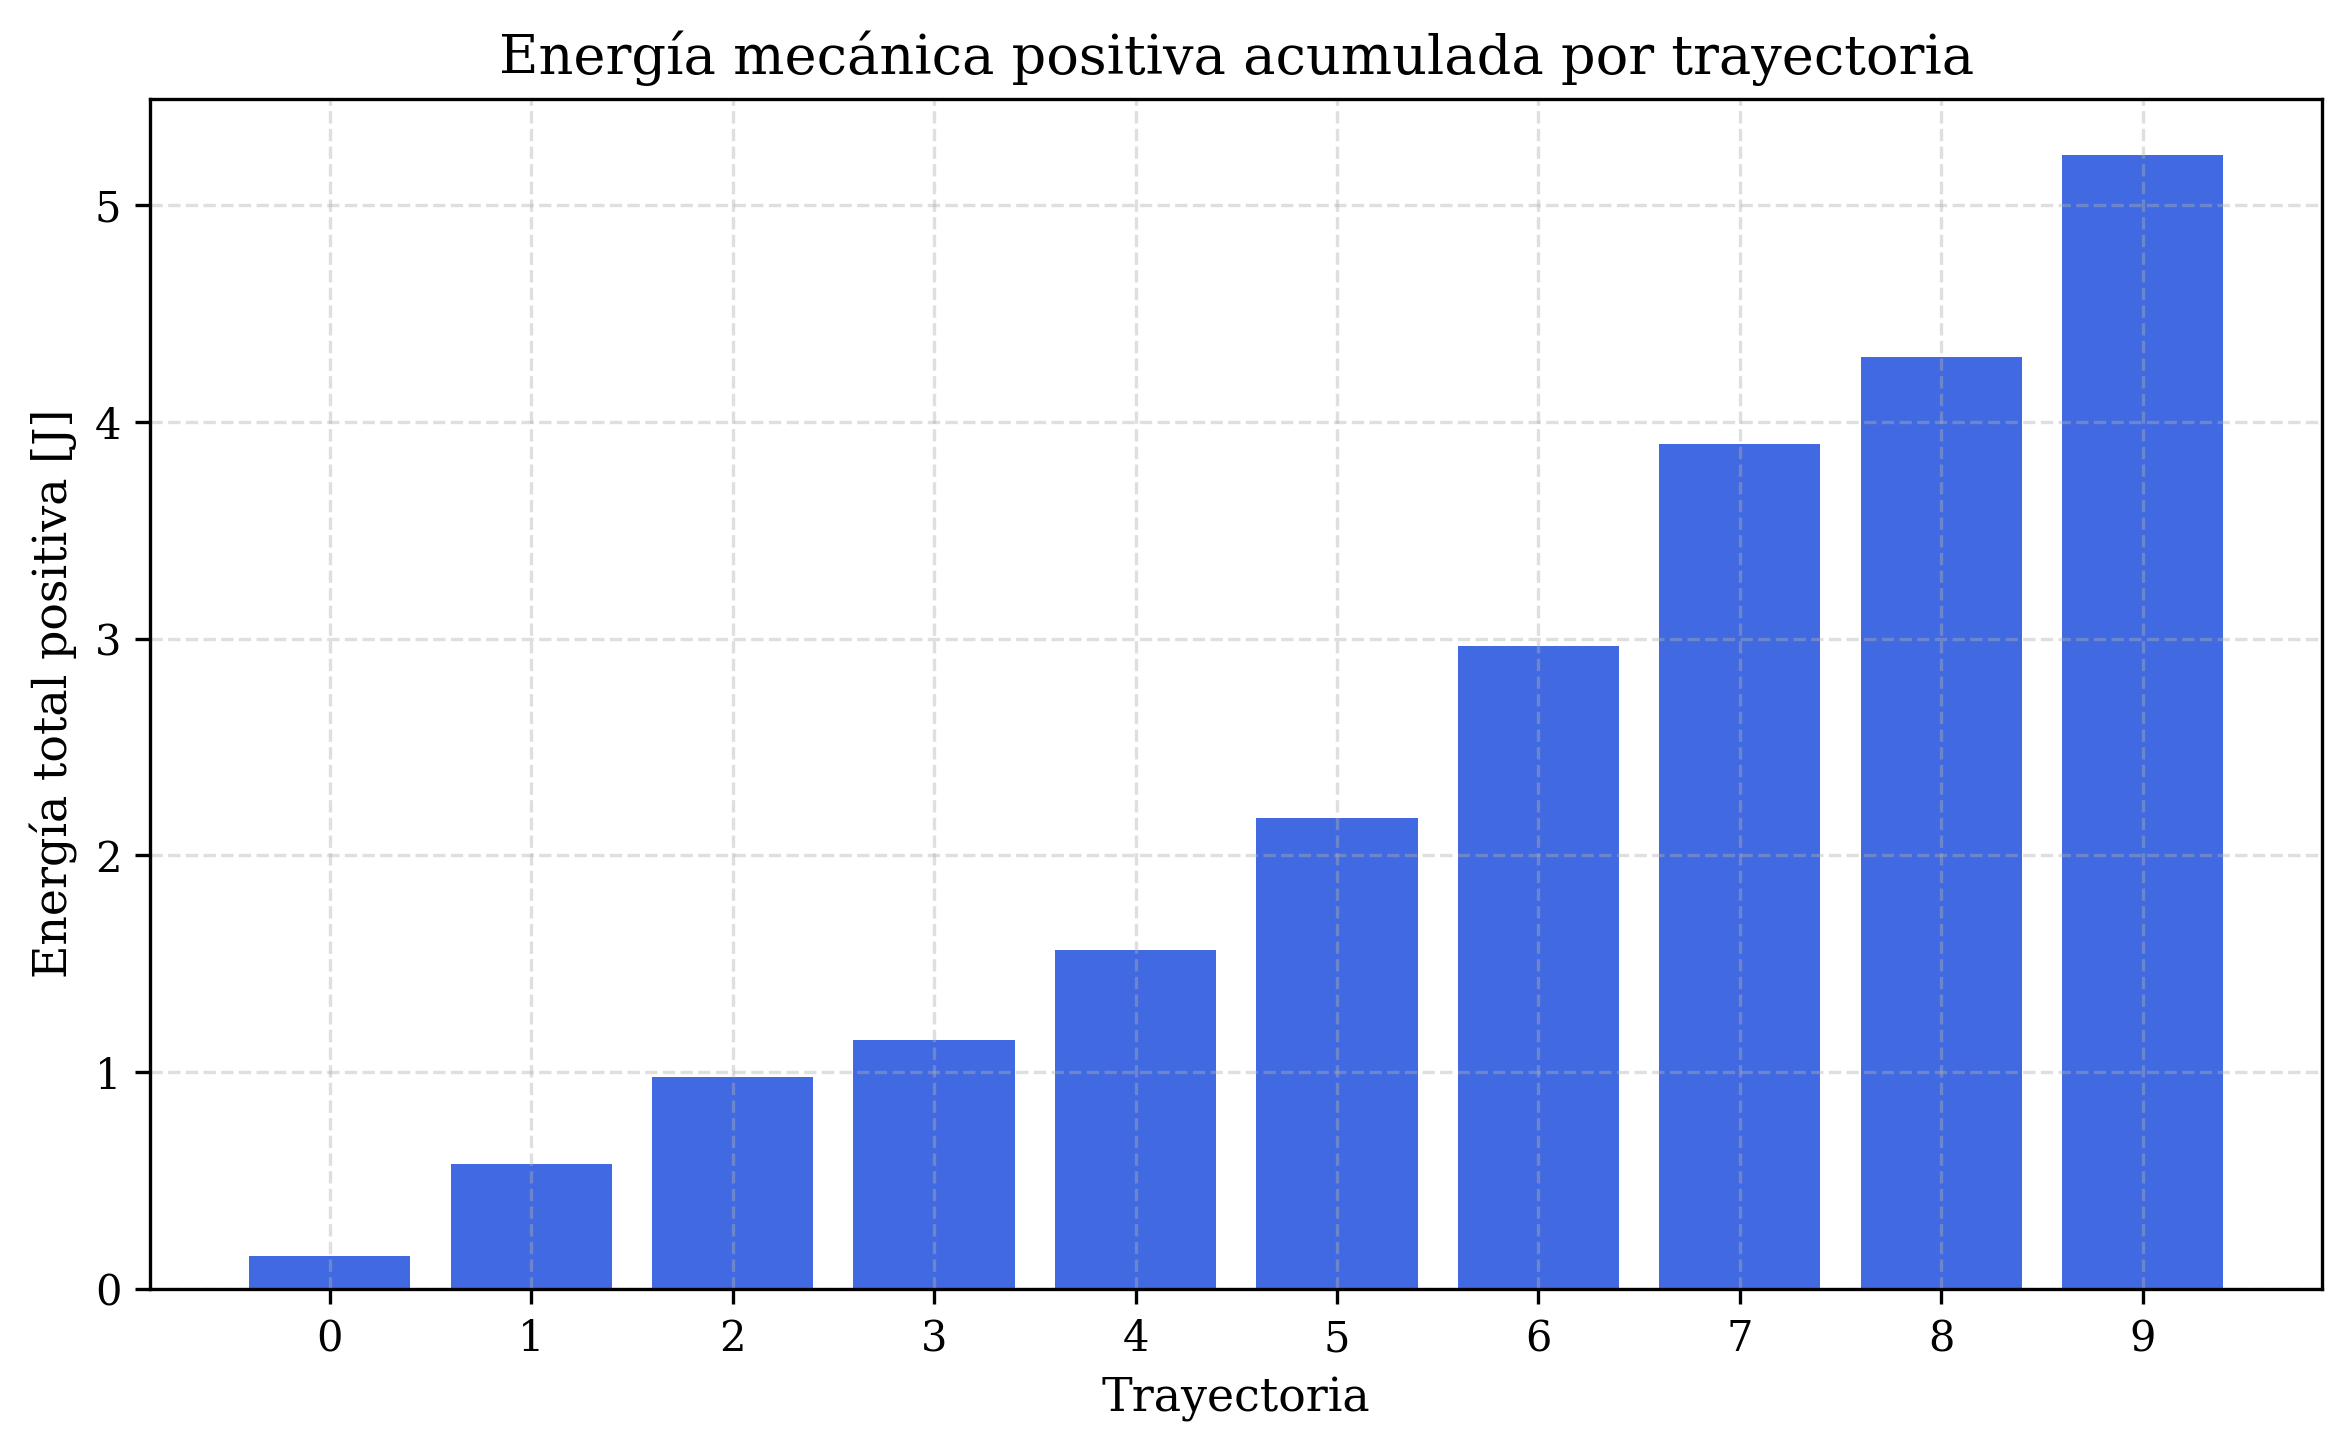

In [64]:

# === Compute energy per trajectory ===
energia_quintic = []

for traj_id in traj_ids:
    # Select go and back segments
    go_seg = df_quintic[(df_quintic['trajectory_num'] == traj_id) & (df_quintic['pick_place_mode'] == 1)]
    back_seg = df_quintic[(df_quintic['trajectory_num'] == traj_id) & (df_quintic['pick_place_mode'] == 2)]

    if go_seg.empty or back_seg.empty:
        continue

    # Time stitching
    t1 = go_seg['time'].values
    t2 = back_seg['time'].values + t1[-1]
    t_all = np.concatenate([t1, t2])

    # Joint signals
    omega1 = np.concatenate([go_seg['omega1'].values, back_seg['omega1'].values])
    omega2 = np.concatenate([go_seg['omega2'].values, back_seg['omega2'].values])
    torque1 = np.concatenate([go_seg['torque1'].values, back_seg['torque1'].values])
    torque2 = np.concatenate([go_seg['torque2'].values, back_seg['torque2'].values])

    # Positive mechanical power
    power1 = np.maximum(torque1 * omega1, 0)
    power2 = np.maximum(torque2 * omega2, 0)

    # Integrate energy [Joules]
    energia1 = np.trapezoid(power1, t_all)
    energia2 = np.trapezoid(power2, t_all)

    energia_quintic.append({
        'trayectoria': traj_id,
        'energia_total_J': energia1 + energia2
    })

# === Create DataFrame ===
df_energia_quintic = pd.DataFrame(energia_quintic)

# === Bar plot ===
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_energia_quintic['trayectoria'], df_energia_quintic['energia_total_J'], color='royalblue')

ax.set_xlabel("Trayectoria", fontsize=11)
ax.set_ylabel("Energía total positiva [J]", fontsize=11)
ax.set_title("Energía mecánica positiva acumulada por trayectoria", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xticks(df_energia_quintic['trayectoria'])  # Ensure tick labels match

plt.tight_layout()
plt.show()

In [95]:
df_energia_quintic.to_csv(os.path.join(data_folder, 'df_energia_quintic.csv'), index=False)

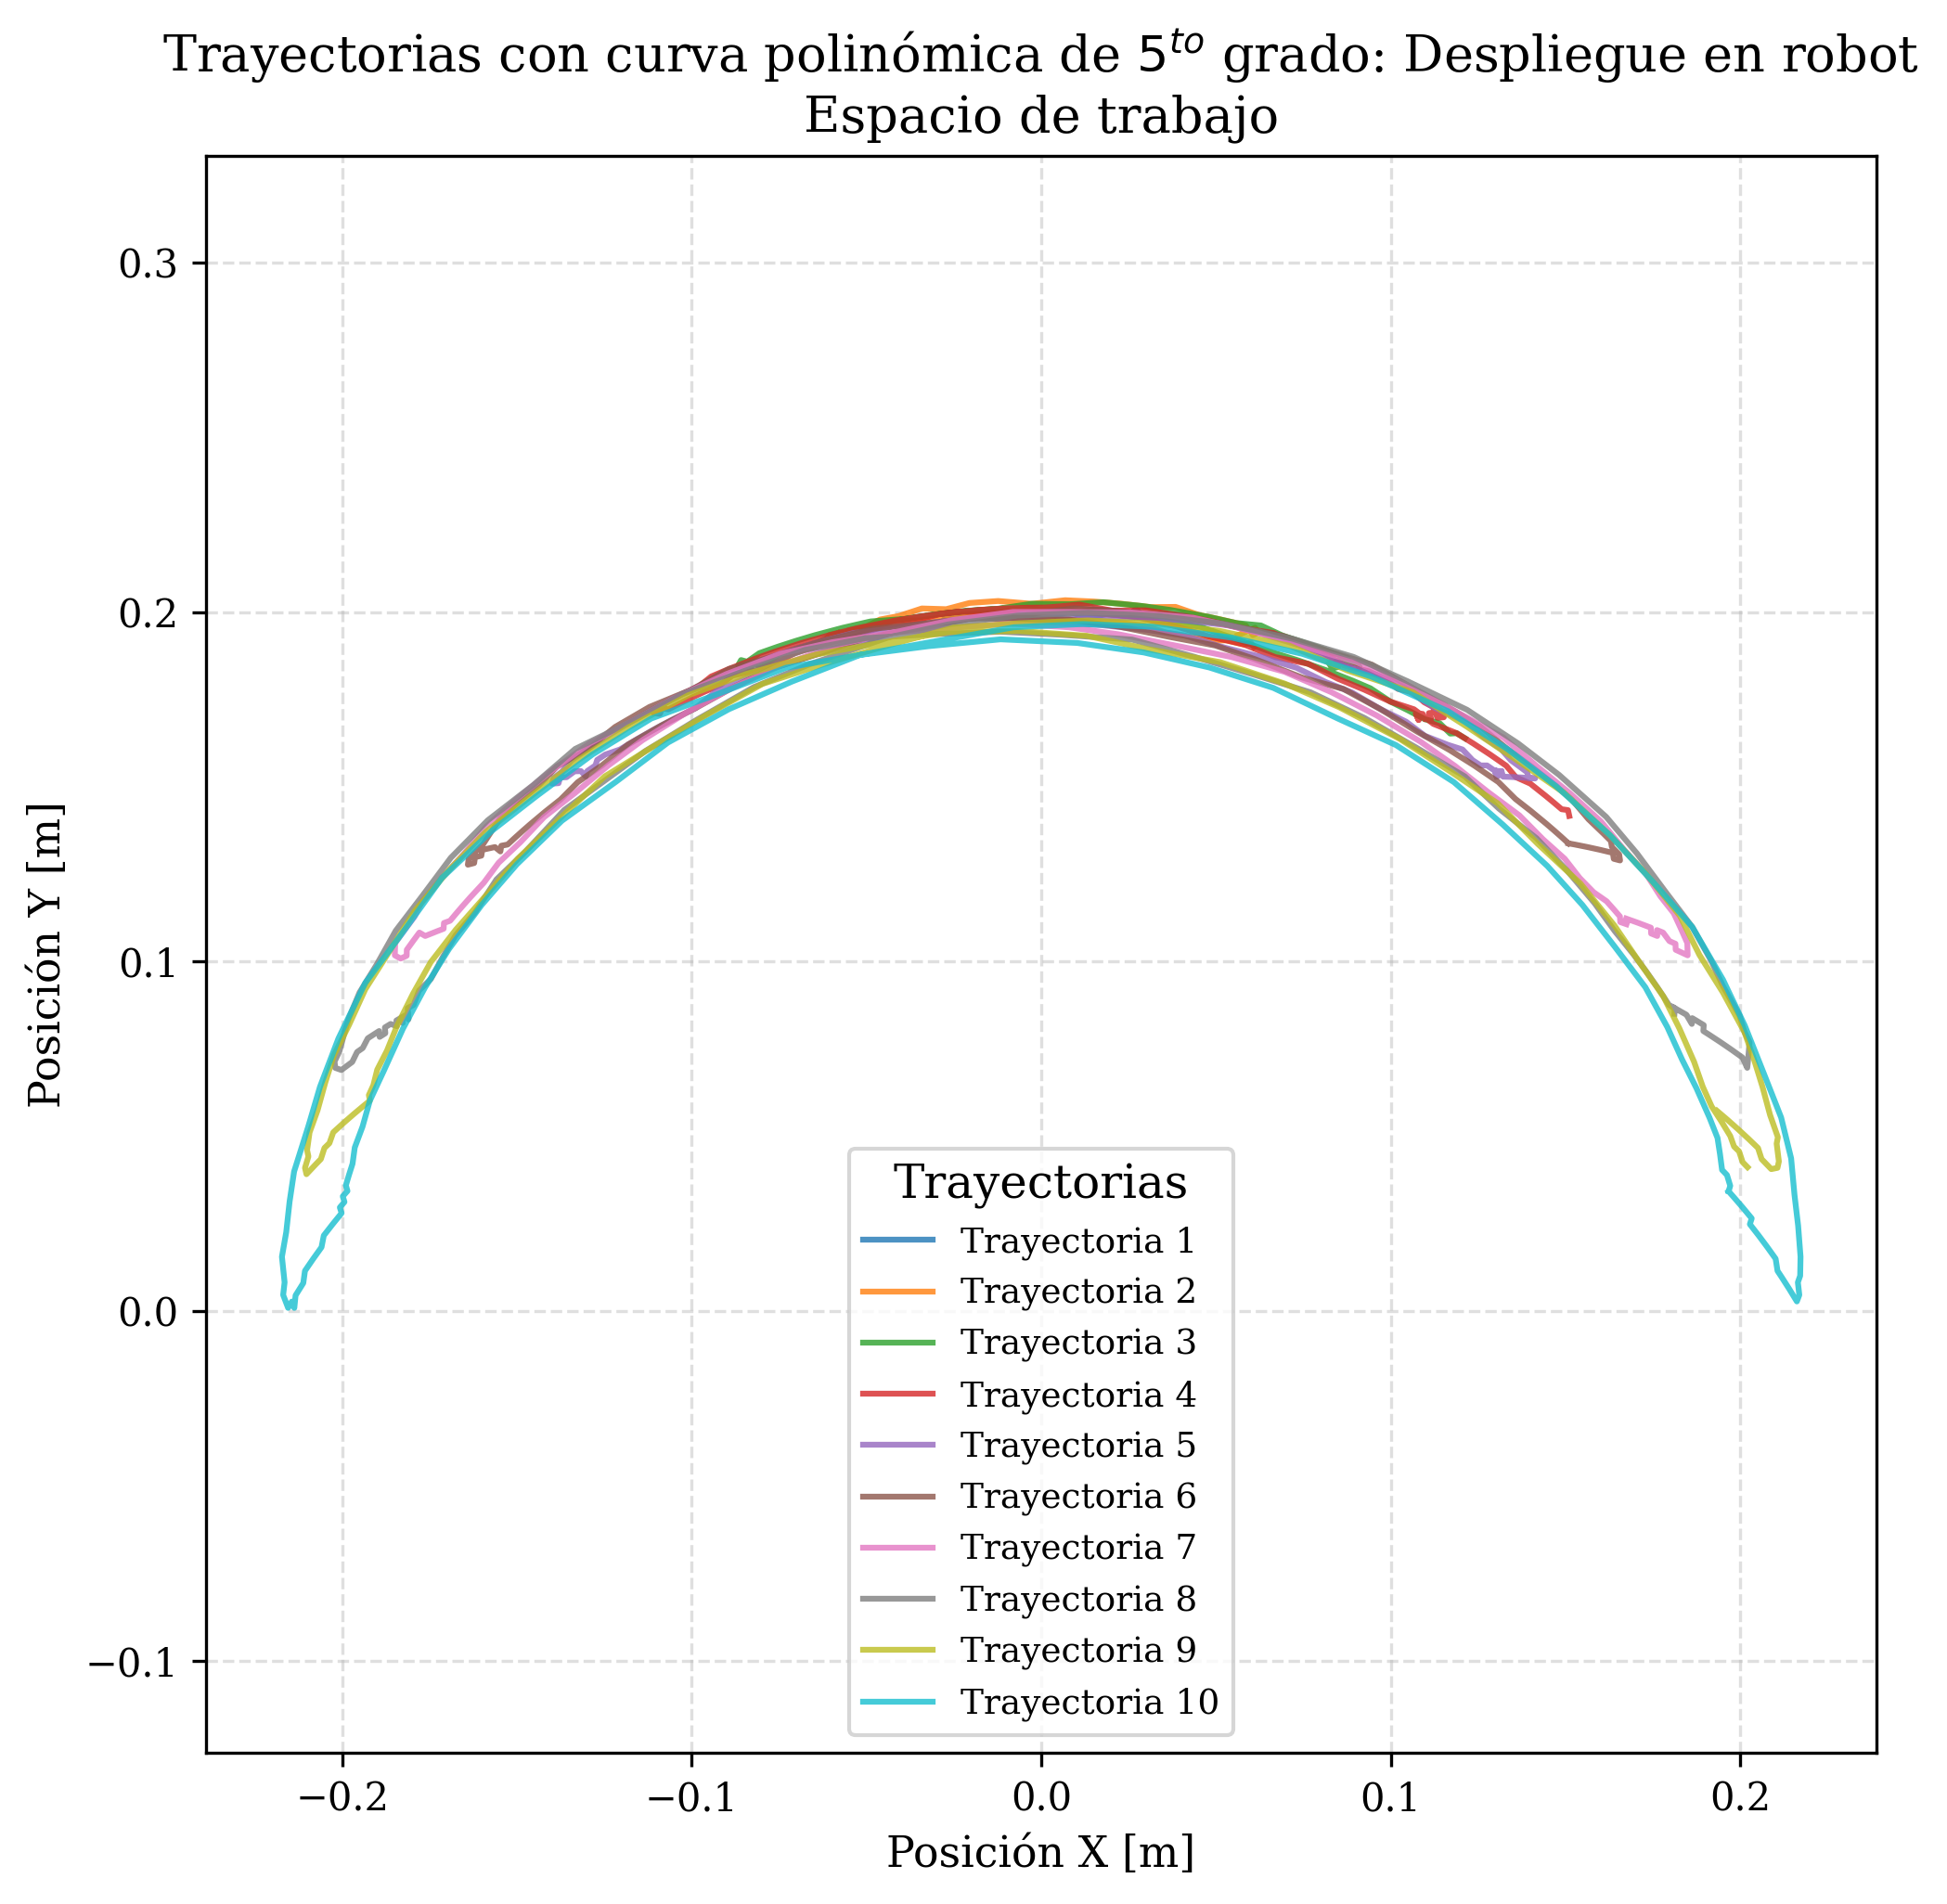

In [74]:

# Extract trajectory IDs
traj_ids = sorted(df_quintic['trajectory_num'].unique())

# Set up plot
fig, ax = plt.subplots(figsize=(7, 7))
color_map = plt.get_cmap("tab10")

# Plot one line per trajectory (stitched mode 1 and 2)
for i, traj_id in enumerate(traj_ids):
    seg1 = df_quintic[(df_quintic['trajectory_num'] == traj_id) & (df_quintic['pick_place_mode'] == 1)]
    seg2 = df_quintic[(df_quintic['trajectory_num'] == traj_id) & (df_quintic['pick_place_mode'] == 2)]

    if seg1.empty or seg2.empty:
        continue

    eff_x = np.concatenate([seg1['eff_x'].values, seg2['eff_x'].values])
    eff_y = np.concatenate([seg1['eff_y'].values, seg2['eff_y'].values])

    ax.plot(eff_x, eff_y, color=color_map(i % 10), label=f"Trayectoria {traj_id+1}", alpha=0.8)

# Formatting
ax.set_title("Trayectorias con curva polinómica de $5^{to}$ grado: Despliegue en robot \nEspacio de trabajo", fontsize=13)
ax.set_xlabel("Posición X [m]", fontsize=11)
ax.set_ylabel("Posición Y [m]", fontsize=11)
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=9, title="Trayectorias")

plt.tight_layout()
plt.show()

In [61]:
robot.reactivate()

In [88]:
robot.set_control_mode("torque")

Control Mode set to 'torque'. Setting targets to [0, 0]



In [89]:

rb_data=robot.get_motors_data()
rb_angles=np.deg2rad(rb_data['angle'])
rb_speed=np.deg2rad(rb_data['speed'])
q_rb,dq_rb,_,_=direct_kinematics(q_base,rb_angles[0],rb_angles[1],rb_speed[0],rb_speed[1],0,0)
q_rb_est=q_rb
rb_eff=[q_rb[3]+0.1*np.cos(q_rb[5]),q_rb[4]+0.1*np.sin(q_rb[5])]

pickplace_mode = 0
target_idx = 0

mode_durations = {0: 3.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 0.5}

target=[pts[target_idx][0][0],pts[target_idx][0][1]]

duration=100

t_init=time.time()
dt=0.01

data_log=[]

t_0=time.time()
while time.time()-t_init<duration:
    
    rb_data=robot.get_motors_data()
    rb_angles=np.deg2rad(rb_data['angle'])
    rb_speed=np.deg2rad(rb_data['speed'])
    q_rb,dq_rb,_,_=direct_kinematics(q_rb_est,rb_angles[0],rb_angles[1],rb_speed[0],rb_speed[1],0,0)
    rb_eff=[q_rb[3]+0.1*np.cos(q_rb[5]),q_rb[4]+0.1*np.sin(q_rb[5])]
    q_est=q_rb+dt*dq_rb
    
    
    obs = np.concatenate([
        np.cos(rb_angles),
        np.sin(rb_angles),
        target,
        rb_speed,
        [rb_eff[0] - target[0], rb_eff[1] - target[1]]
    ])
    
    action, _ = RL_model.predict(obs, deterministic=True)
    
    robot.set_target(1.6*action[0],1.6*action[1])
    
    
    
    if time.time() - t_0 > mode_durations[pickplace_mode]:
        t_0 = time.time()

        if pickplace_mode == 0:
            pickplace_mode = 1
            target=[pts[target_idx][1][0],pts[target_idx][1][1]]   # pick → place

        elif pickplace_mode == 1:
            pickplace_mode = 2
            target=[pts[target_idx][0][0],pts[target_idx][0][1]]

        elif pickplace_mode == 2:
            pickplace_mode = 3
            target=[pts[target_idx][1][0],pts[target_idx][1][1]]

        elif pickplace_mode == 3:
            pickplace_mode = 4
            if target_idx + 1 < len(pts):
                target=[pts[target_idx + 1][0][0],pts[target_idx + 1][0][1]]
            else:
                break  # end of trajectory list

        elif pickplace_mode == 4:
            target_idx += 1
            if target_idx < len(pts):
                pickplace_mode = 0
                target=[pts[target_idx][0][0],pts[target_idx][0][1]]
            else:
                break

    # === Logging: only for pick→place and place→pick ===
    if pickplace_mode in [1, 2]:
        data_log.append({
            'trajectory_num': target_idx,
            'pick_place_mode': pickplace_mode,
            'time': time.time() - t_0,
            'target': tuple(target),
            'torque1': 1.6*action[0],
            'torque2': 1.6*action[1],
            'theta1': rb_angles[0],
            'theta2': rb_angles[1],
            'omega1': rb_speed[0],
            'omega2': rb_speed[1],
            'eff_x': q_rb[3]+0.1*np.cos(q_rb[5]),
            'eff_y': q_rb[4]+0.1*np.sin(q_rb[5]),
        })
    time.sleep(dt)

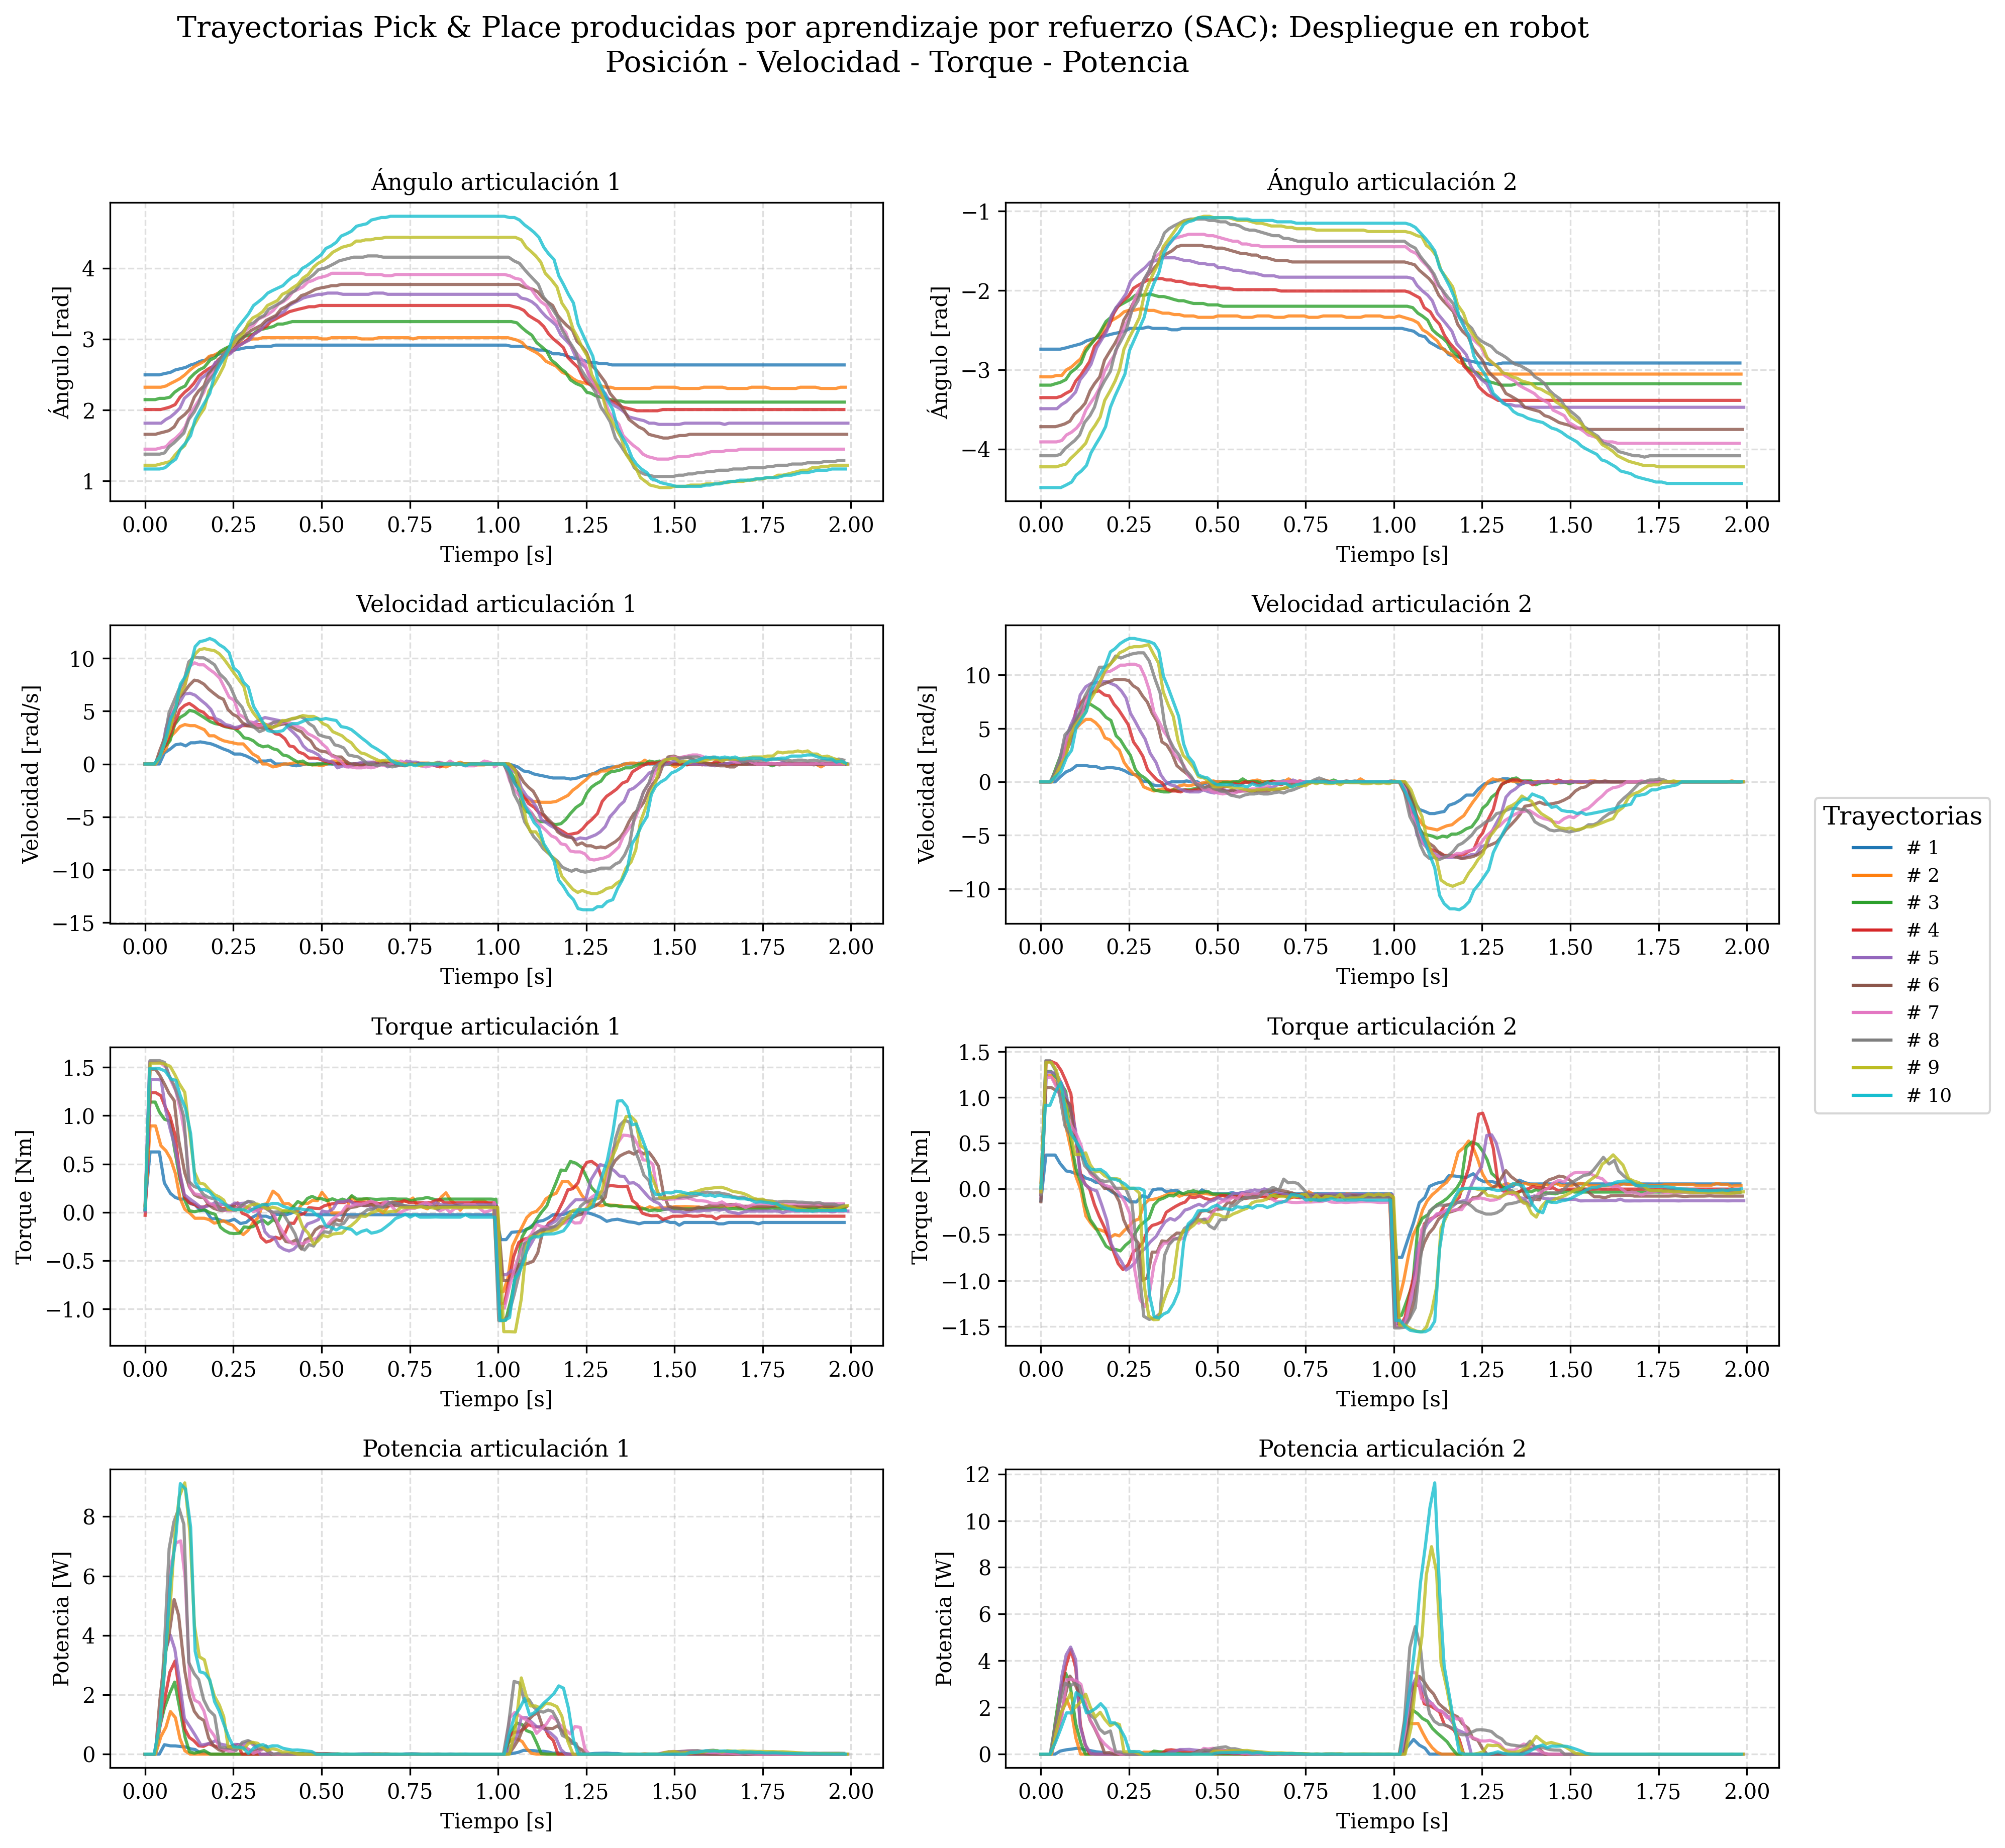

In [75]:

# Load data
df = pd.DataFrame(data_log)

# Separate motion phases
pick_df = df[df['pick_place_mode'] == 1]
place_df = df[df['pick_place_mode'] == 2]

traj_ids = sorted(df['trajectory_num'].unique())
# Crear figura con 4 filas (ángulo, velocidad, torque, potencia)
fig, axes = plt.subplots(4, 2, figsize=(12, 12), sharex=False)

# Color cycle
color_map = plt.get_cmap("tab10")
legend_lines = []

for i, traj_id in enumerate(traj_ids):
    pick_seg = pick_df[pick_df['trajectory_num'] == traj_id]
    place_seg = place_df[place_df['trajectory_num'] == traj_id]

    if pick_seg.empty or place_seg.empty:
        continue

    # Time stitching
    t1 = pick_seg['time'].values
    t2 = place_seg['time'].values + t1[-1]
    t_all = np.concatenate([t1, t2])

    color = color_map(i % 10)

    # === Datos originales ===
    theta1 = np.concatenate([pick_seg['theta1'].values, place_seg['theta1'].values])
    theta2 = np.concatenate([pick_seg['theta2'].values, place_seg['theta2'].values])
    omega1 = np.concatenate([pick_seg['omega1'].values, place_seg['omega1'].values])
    omega2 = np.concatenate([pick_seg['omega2'].values, place_seg['omega2'].values])
    torque1 = np.concatenate([pick_seg['torque1'].values, place_seg['torque1'].values])
    torque2 = np.concatenate([pick_seg['torque2'].values, place_seg['torque2'].values])

    # === Potencia positiva ===
    power1 = np.maximum(torque1 * omega1, 0)
    power2 = np.maximum(torque2 * omega2, 0)

    # === Graficar ===
    axes[0, 0].plot(t_all, theta1, alpha=0.8, color=color)
    axes[0, 1].plot(t_all, theta2, alpha=0.8, color=color)
    axes[1, 0].plot(t_all, omega1, alpha=0.8, color=color)
    axes[1, 1].plot(t_all, omega2, alpha=0.8, color=color)
    axes[2, 0].plot(t_all, torque1, alpha=0.8, color=color)
    axes[2, 1].plot(t_all, torque2, alpha=0.8, color=color)
    axes[3, 0].plot(t_all, power1, alpha=0.8, color=color)
    axes[3, 1].plot(t_all, power2, alpha=0.8, color=color)

    # Leyenda global
    legend_lines.append(plt.Line2D([], [], color=color, label=f"# {traj_id+1}"))


# === Titles, labels, grid ===

titles = [["Ángulo articulación 1", "Ángulo articulación 2"],
          ["Velocidad articulación 1", "Velocidad articulación 2"],
          ["Torque articulación 1", "Torque articulación 2"],
          ["Potencia articulación 1", "Potencia articulación 2"]]

ylabels = [["Ángulo [rad]"]*2,
           ["Velocidad [rad/s]"]*2,
           ["Torque [Nm]"]*2,
           ["Potencia [W]"]*2]

for row in range(4):
    for col in range(2):
        ax = axes[row, col]
        ax.set_title(titles[row][col], fontsize=11)
        ax.set_ylabel(ylabels[row][col], fontsize=10)
        ax.set_xlabel("Tiempo [s]", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)

# === Global legend on the right ===
fig.legend(handles=legend_lines, loc='center left', bbox_to_anchor=(1.01, 0.5),
           borderaxespad=0, fontsize=9, title="Trayectorias")

# === Suptitle ===
plt.suptitle("Trayectorias Pick & Place producidas por aprendizaje por refuerzo (SAC): Despliegue en robot  \n Posición - Velocidad - Torque - Potencia", fontsize=14, y=1.02)

plt.tight_layout()
plt.subplots_adjust(right=0.99)  # make room for the right-side legend
plt.show()

In [98]:
df.to_csv(os.path.join(data_folder, 'df_rl.csv'), index=False)

C:\Users\juanp\AppData\Local\Temp\ipykernel_31212\1030069604.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energia1 = np.trapz(power1, t_all)
C:\Users\juanp\AppData\Local\Temp\ipykernel_31212\1030069604.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energia2 = np.trapz(power2, t_all)


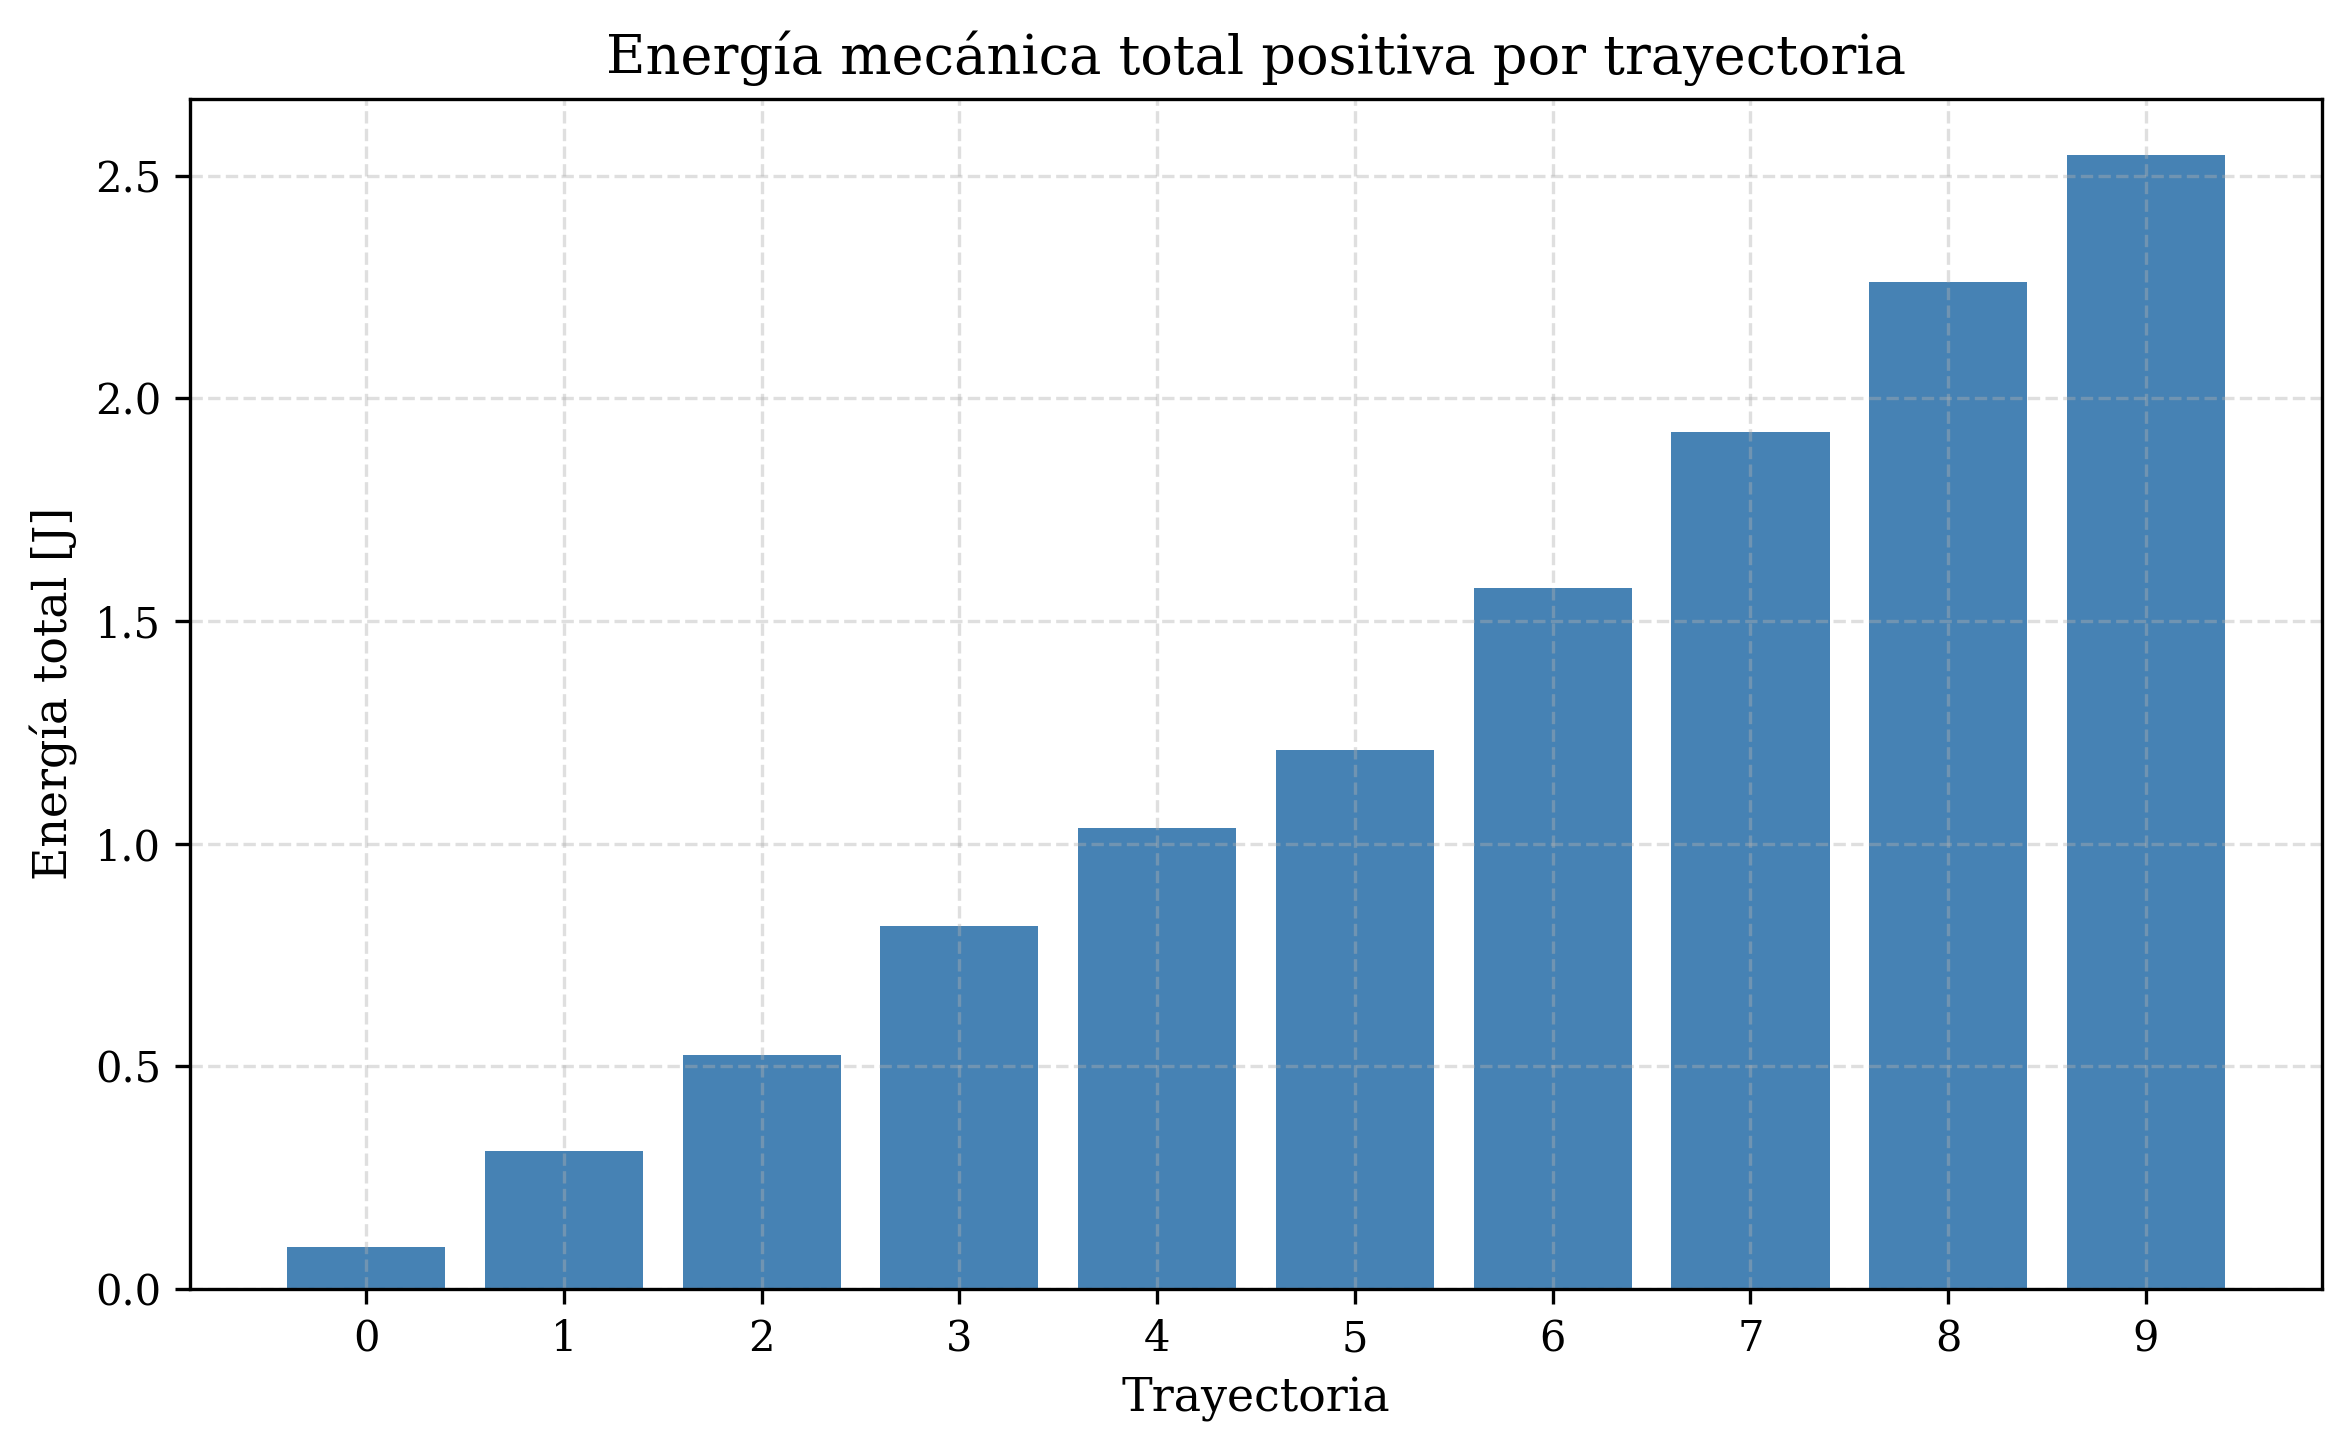

In [18]:
energia_total = []

for traj_id in traj_ids:
    pick_seg = pick_df[pick_df['trajectory_num'] == traj_id]
    place_seg = place_df[place_df['trajectory_num'] == traj_id]

    if pick_seg.empty or place_seg.empty:
        continue

    t1 = pick_seg['time'].values
    t2 = place_seg['time'].values + t1[-1]
    t_all = np.concatenate([t1, t2])

    omega1 = np.concatenate([pick_seg['omega1'].values, place_seg['omega1'].values])
    omega2 = np.concatenate([pick_seg['omega2'].values, place_seg['omega2'].values])
    torque1 = np.concatenate([pick_seg['torque1'].values, place_seg['torque1'].values])
    torque2 = np.concatenate([pick_seg['torque2'].values, place_seg['torque2'].values])

    power1 = np.maximum(torque1 * omega1, 0)
    power2 = np.maximum(torque2 * omega2, 0)

    energia1 = np.trapz(power1, t_all)
    energia2 = np.trapz(power2, t_all)
    energia_total.append({'trayectoria': traj_id, 'energia_total_J': energia1 + energia2})

# Convertir a DataFrame
df_energia = pd.DataFrame(energia_total)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_energia['trayectoria'], df_energia['energia_total_J'], color='steelblue')

ax.set_xlabel("Trayectoria", fontsize=11)
ax.set_ylabel("Energía total [J]", fontsize=11)
ax.set_title("Energía mecánica total positiva por trayectoria", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xticks(df_energia['trayectoria'])  # asegúrate de mostrar todos los ticks

plt.tight_layout()
plt.show()

In [99]:
df_energia.to_csv(os.path.join(data_folder, 'df_energia_rl.csv'), index=False)

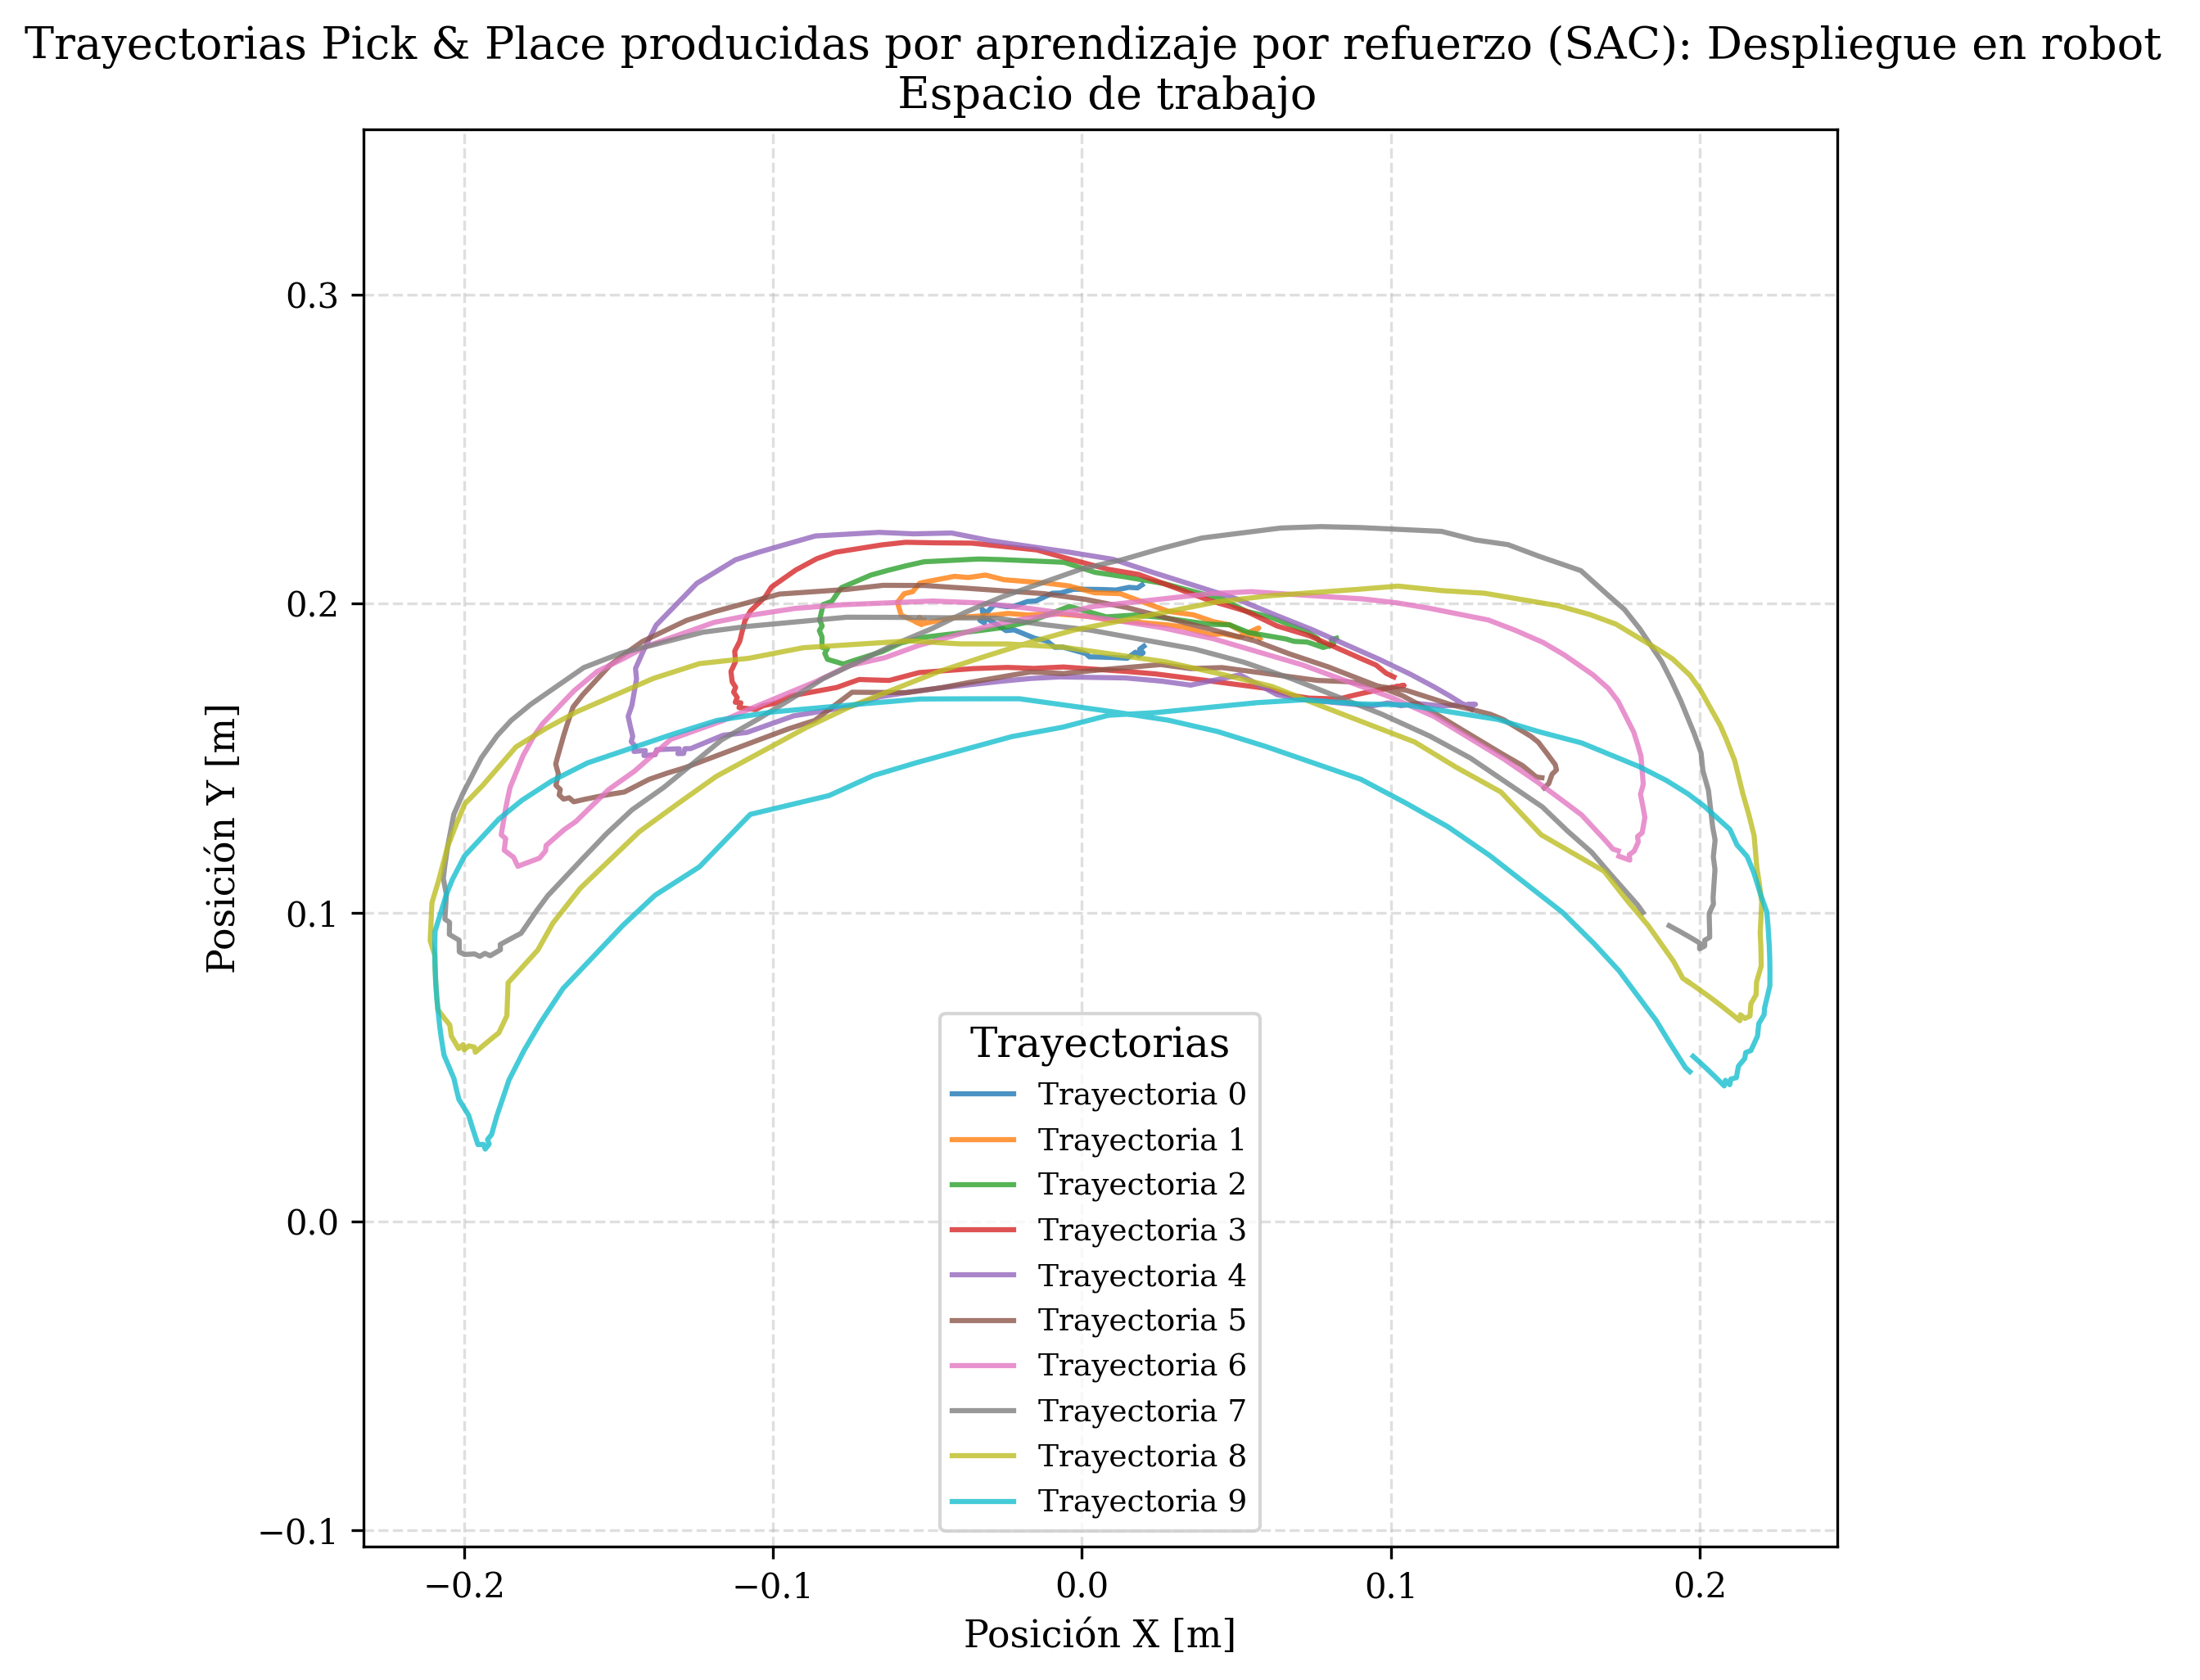

In [76]:
# Filtrar movimientos relevantes
pick_df = df[df['pick_place_mode'] == 1]
place_df = df[df['pick_place_mode'] == 2]

traj_ids = sorted(df['trajectory_num'].unique())

# Crear figura
fig, ax = plt.subplots(figsize=(7, 7))
color_map = plt.get_cmap("tab10")

for i, traj_id in enumerate(traj_ids):
    pick_seg = pick_df[pick_df['trajectory_num'] == traj_id]
    place_seg = place_df[place_df['trajectory_num'] == traj_id]

    if pick_seg.empty or place_seg.empty:
        continue

    # Concatenar trayectorias: pick → place → pick
    eff_x = np.concatenate([pick_seg['eff_x'].values, place_seg['eff_x'].values])
    eff_y = np.concatenate([pick_seg['eff_y'].values, place_seg['eff_y'].values])

    color = color_map(i % 10)
    ax.plot(eff_x, eff_y, color=color, label=f"Trayectoria {traj_id}", alpha=0.8)

# Formato de la gráfica
ax.set_title("Trayectorias Pick & Place producidas por aprendizaje por refuerzo (SAC): Despliegue en robot \n Espacio de trabajo", fontsize=13)
ax.set_xlabel("Posición X [m]", fontsize=11)
ax.set_ylabel("Posición Y [m]", fontsize=11)
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=9, title="Trayectorias", loc='best')

plt.tight_layout()
plt.show()

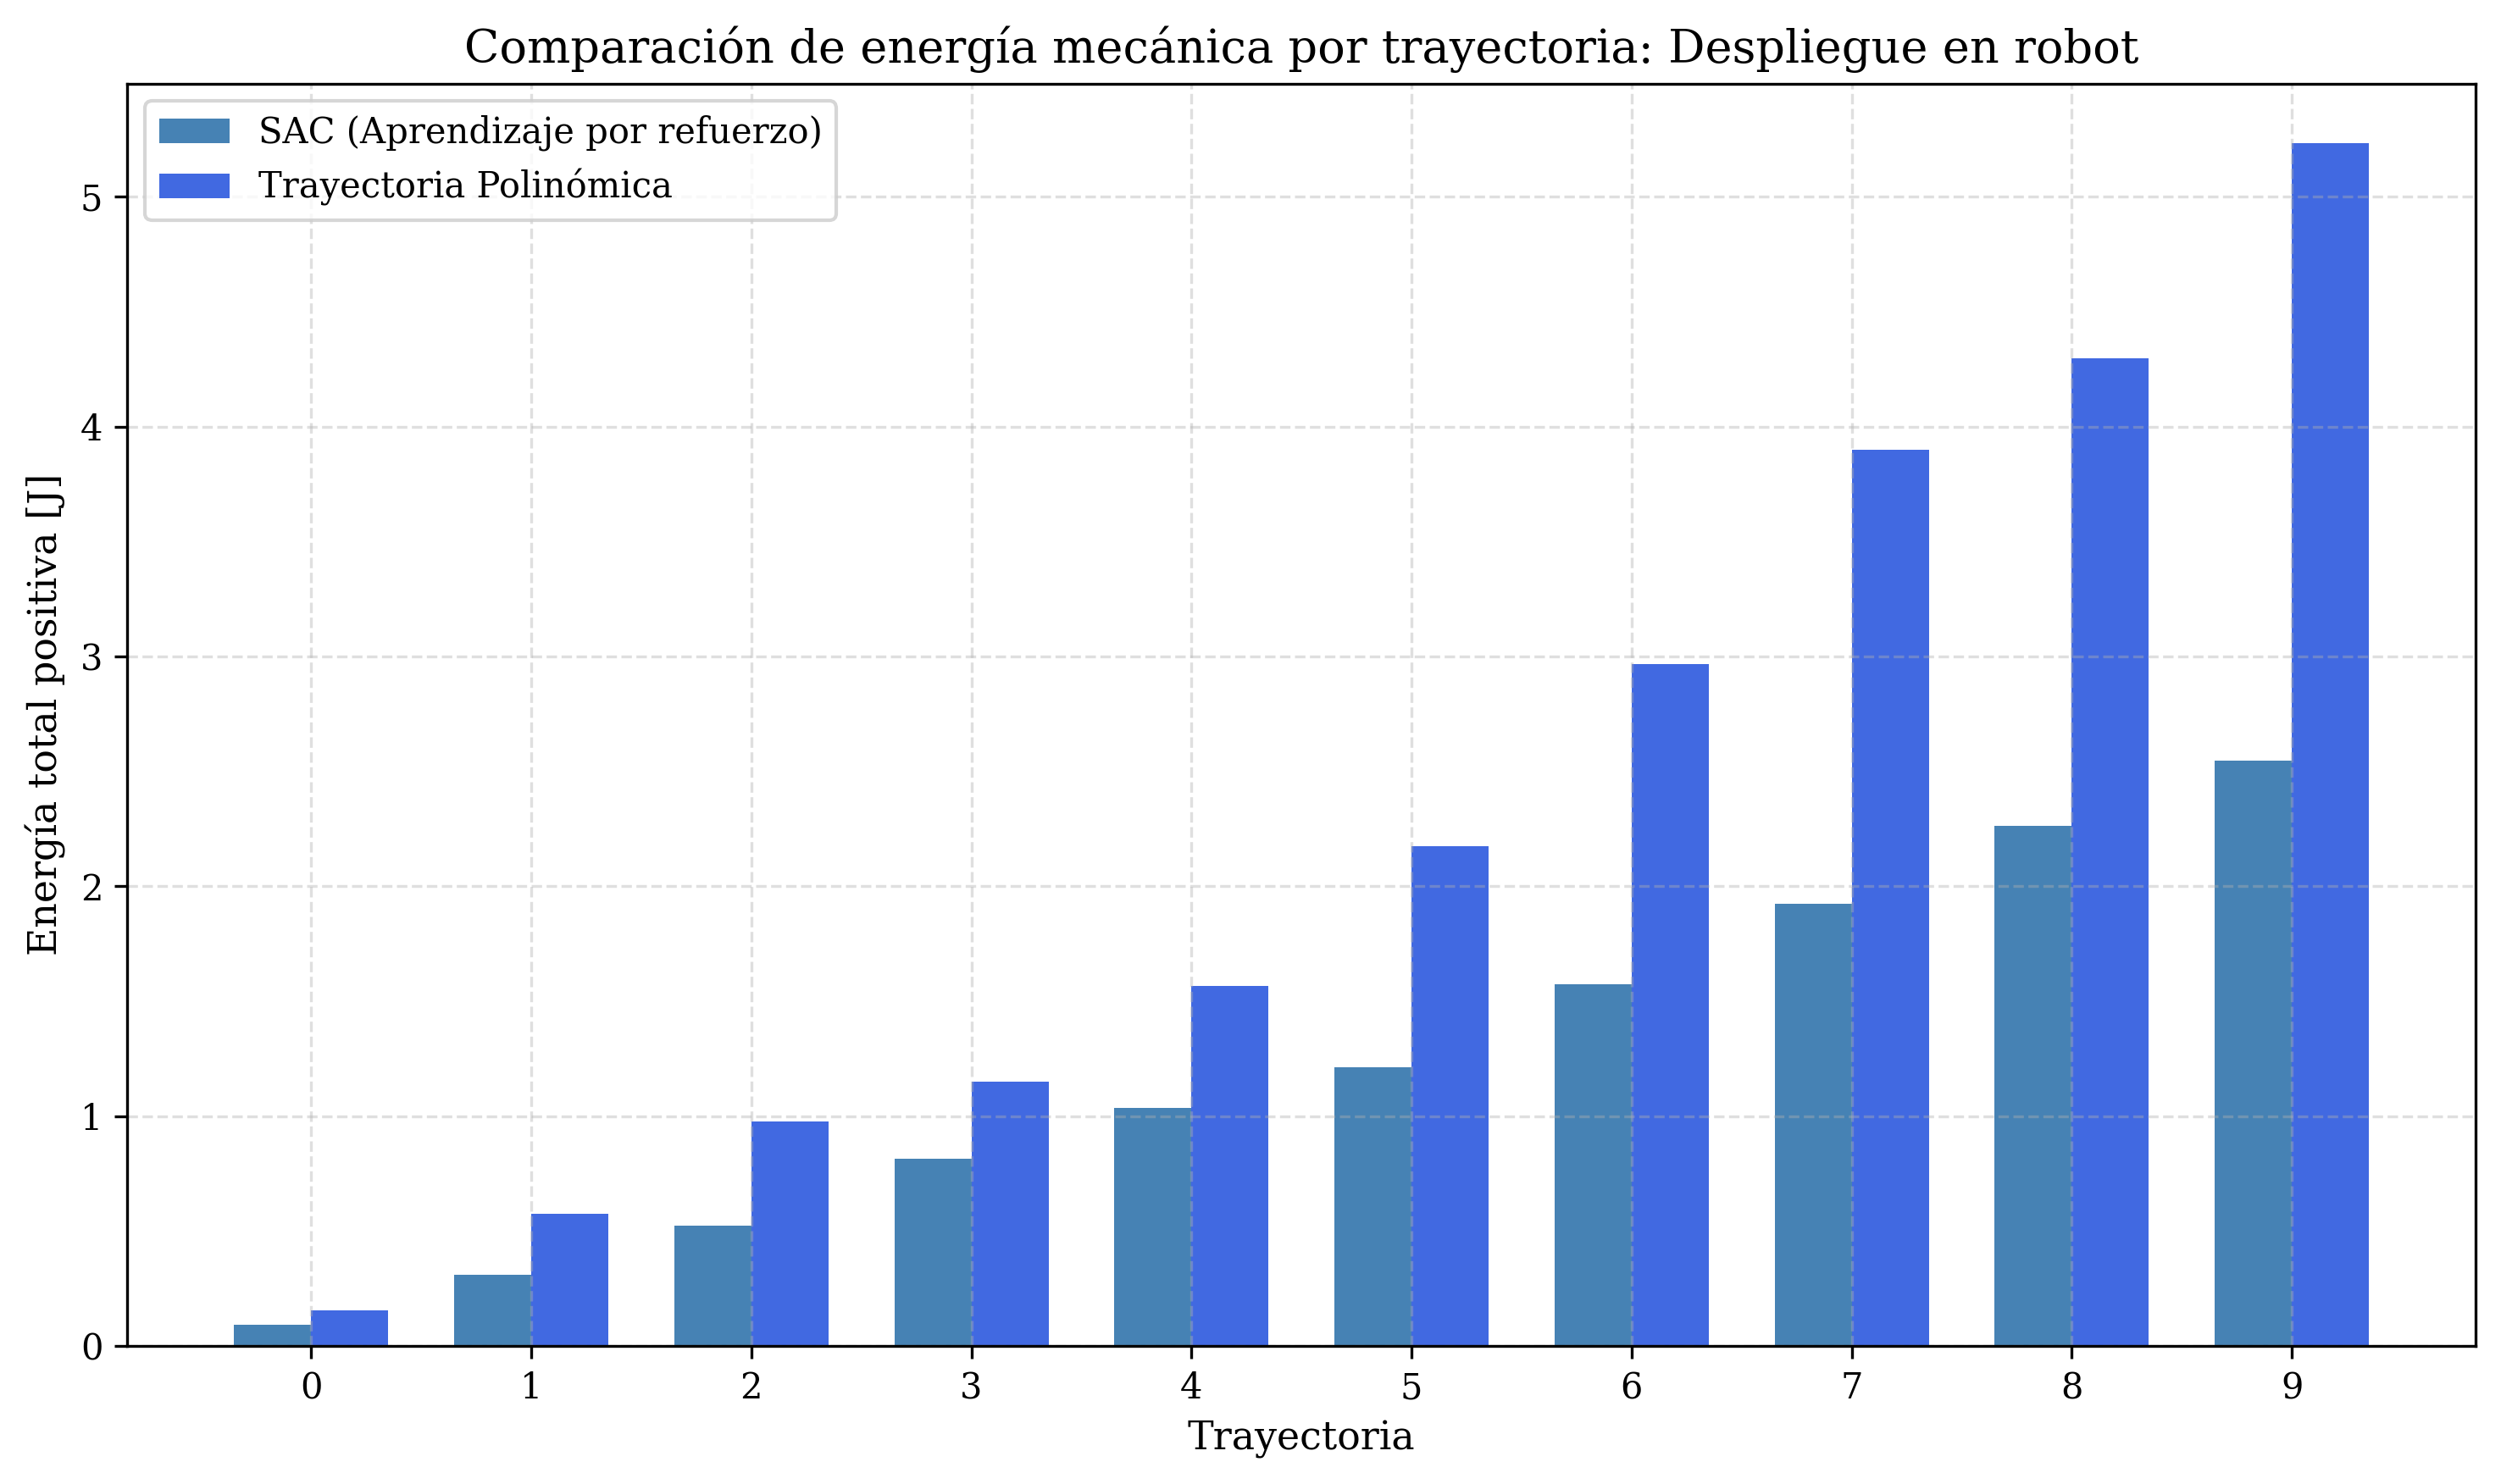

In [80]:
# === Merge data on trajectory number ===
df_comparativa = pd.merge(df_energia, df_energia_quintic, on='trayectoria', suffixes=('_sac', '_quintic'))

# === Prepare bar plot positions ===
x = np.arange(len(df_comparativa))  # trajectory indices
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# === Bar plots ===
bars1 = ax.bar(x - width/2, df_comparativa['energia_total_J_sac'], width, label='SAC (Aprendizaje por refuerzo)', color='steelblue')
bars2 = ax.bar(x + width/2, df_comparativa['energia_total_J_quintic'], width, label='Trayectoria Polinómica', color='royalblue')

# === Labels and formatting ===
ax.set_xlabel("Trayectoria", fontsize=11)
ax.set_ylabel("Energía total positiva [J]", fontsize=11)
ax.set_title("Comparación de energía mecánica por trayectoria: Despliegue en robot", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_comparativa['trayectoria'])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [100]:
df_comparativa.to_csv(os.path.join(data_folder, 'df_comparativa.csv'), index=False)